# ECON 398 Project Workbook

Authors: *William Clinton Co, Jerrold Huang, Jae Park, Kaiyan Zhang, Irene Berezin*

### Package Loading

In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(haven)
library(lubridate)
library(stargazer)
library(units)
library(broom)
library(sf)
library(fixest)
library(patchwork)
library(lmtest)
library(pscl)
library(vcd)
library(tableone)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"


Warning message:
"package 'ggplot2' was built under R version 4.4.2"
Warning message:
"package 'dplyr' was built under R version 4.4.2"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 


udunits database from C:/Users/Kaiyan Zhang/AppData/Local/R/win-library/4.4/units/share/udunits/udunits2.xml

Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.3

### Data Preprocessing (Pulling Data for 2021 Census)

In [2]:
# reading in cancensus data for 2021
census2021 <- read_csv("census2021_raw.csv")|>
    glimpse()


Rows: 1016 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): Type
dbl (12): GeoUID, Region Name, Area (sq km), Population, Dwellings, Househol...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 1,016
Columns: 13
$ GeoUID                                                                <dbl> …
$ Type                                                                  <chr> …
$ `Region Name`                                                         <dbl> …
$ `Area (sq km)`                                                        <dbl> …
$ Population                                                            <dbl> …
$ Dwellings                                                             <dbl> …
$ Households                                                            <dbl> …
$ `v_CA21_1: Population, 2021`                                          <dbl> …
$ `v_CA21_6: Population density per square kilometre`                   <dbl> …
$ `v_CA21_386: Average age`                                             <dbl> …
$ `v_CA21_906: Median total income of household in 2020 ($)`            <dbl> …
$ `v_CA21_5853: University certificate or diploma above bachelor level` <dbl> …
$ `v_CA21_4410: 

In [3]:
census2021_clean <- census2021|>
    rename(name = `GeoUID`,
        households = Households, 
        dwellings = Dwellings, 
        population =  `v_CA21_1: Population, 2021`,
        population_density = `v_CA21_6: Population density per square kilometre`, 
        region = `Region Name`, 
        area_sq_km = `Area (sq km)`, 
        age =  `v_CA21_386: Average age`, 
        income = `v_CA21_906: Median total income of household in 2020 ($)`,
        education = `v_CA21_5853: University certificate or diploma above bachelor level`,
        immigrant = `v_CA21_4410: Immigrants`)|>
    mutate(immigrant_prop = immigrant/population) |>
    mutate(university_prop = education / population)|>
    mutate(income = income / 100000)|>
    select(name, households, dwellings, population,population_density, area_sq_km, age, income, immigrant_prop, university_prop)|>
    glimpse()

census2021_clean$name <- as.character(census2021_clean$name)

Rows: 1,016
Columns: 10
$ name               <dbl> 59150307, 59150308, 59150309, 59150310, 59150311, 5…
$ households         <dbl> 266, 218, 282, 389, 187, 201, 355, 169, 350, 209, 3…
$ dwellings          <dbl> 297, 229, 299, 411, 202, 218, 368, 177, 369, 221, 3…
$ population         <dbl> 677, 541, 761, 748, 537, 555, 1003, 508, 966, 544, …
$ population_density <dbl> 2263.5, 4936.1, 6800.7, 6837.3, 6637.8, 6372.0, 580…
$ area_sq_km         <dbl> 0.2991, 0.1096, 0.1119, 0.1094, 0.0809, 0.0871, 0.1…
$ age                <dbl> 42.8, 43.0, 43.3, 37.0, 41.0, 40.6, 45.6, 41.4, 42.…
$ income             <dbl> 1.14, 1.14, 0.94, 0.67, 0.92, 0.96, 0.90, 0.95, 0.8…
$ immigrant_prop     <dbl> 0.2806499, 0.2957486, 0.2759527, 0.2606952, 0.28864…
$ university_prop    <dbl> 0.01477105, 0.04621072, 0.03285151, 0.01336898, 0.0…


### Data Exploration

In [4]:
# Read in the 2016 census data
census2016 <- read_sf("census_index_crime.geojson")|>
    select(- c(crime_count, crime_rate))|>
    rename("university_prop" = "education_prop")|>
    mutate(income = as.double(income),
    immigrant_prop = as.double(immigrant_prop),
    university_prop = as.double(university_prop))|>
    glimpse()

Warning message:
"There were 3 warnings in `stopifnot()`.
The first warning was:
ℹ In argument: `income = as.double(income)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings."


Rows: 993
Columns: 17
$ name                 <chr> "59150307", "59150308", "59150309", "59150310", "…
$ households           <int> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <int> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <int> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <int> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index     

In [5]:
# Read in the crime data
crime_data <- read.csv("Original_Crime_data/crime_in_vancouver_census.csv")|>
    select(type, year, month, name, neighbourhood, time_category)|>
    filter(!is.na(name))|>
    filter(year >= 2014 & year < 2024)|>
    glimpse()

Rows: 351,457
Columns: 6
$ type          <chr> "Break and Enter Commercial", "Break and Enter Commercia…
$ year          <int> 2019, 2019, 2021, 2014, 2020, 2021, 2022, 2014, 2014, 20…
$ month         <int> 3, 8, 4, 8, 7, 11, 1, 4, 9, 1, 11, 11, 3, 6, 9, 6, 2, 2,…
$ name          <int> 59153689, 59153483, 59153483, 59153483, 59153483, 591534…
$ neighbourhood <chr> "Fairview", "West End", "West End", "West End", "West En…
$ time_category <chr> "night", "night", "night", "night", "night", "night", "n…


In [6]:

crime_data <- crime_data|>
    group_by(year, month, name, type, time_category)|>
    summarise(crime_count = n(), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 193,067
Columns: 7
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150309, 591503…
$ type          <chr> "Theft of Vehicle", "Theft from Vehicle", "Mischief", "O…
$ time_category <chr> "night", "night", "day", "day", "night", "night", "night…
$ crime_count   <int> 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


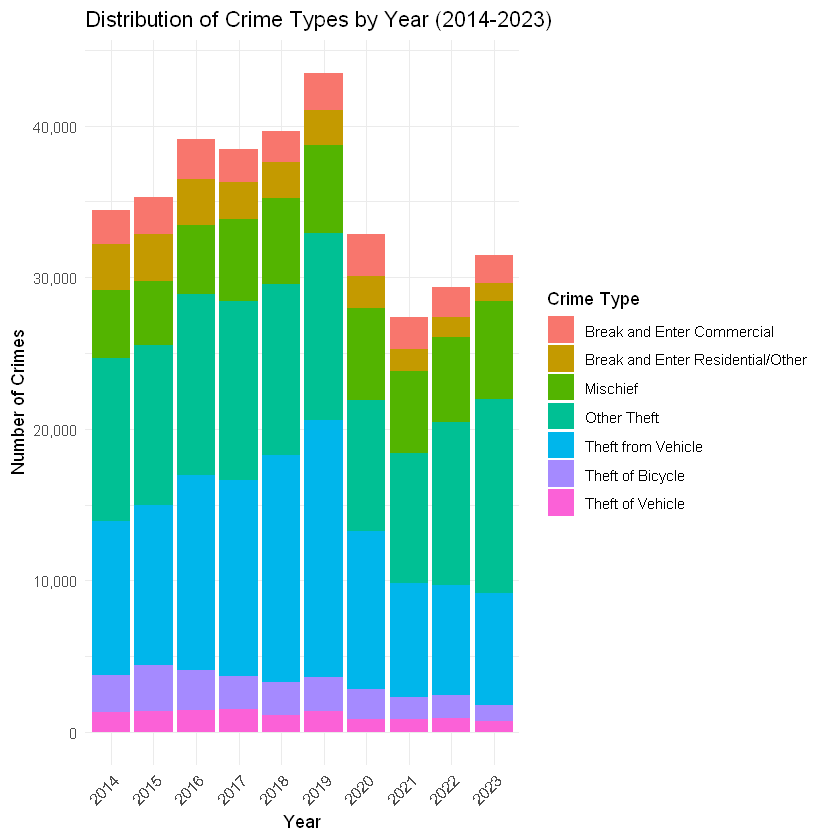

In [7]:
# Visualize the distribution of different types of crimes each year
crime_summary <- crime_data|>
  group_by(year, type)|>
  summarise(total_crimes = sum(crime_count, na.rm = TRUE))|>
  ungroup()

# Create the visualization
ggplot(crime_summary, aes(x = factor(year), y = total_crimes, fill = type)) +
  geom_col(position = "stack") +
  labs(title = "Distribution of Crime Types by Year (2014-2023)",
       x = "Year",
       y = "Number of Crimes",
       fill = "Crime Type") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "right") +
  scale_y_continuous(labels = scales::comma)

The visualization showed some promise in heterogeneous analysis by different crime types, but let's first focus on crime overall, we remove "Mischief" because it is something not so interesting for our study.

In [8]:
# Create a data summarizing all types of crimes together
crime_trend <- crime_data|>
    filter(type != "Mischief")|>
    group_by(year, month, name, time_category)|>
    summarise(crime_count = sum(crime_count), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 104,703
Columns: 6
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150310, 591503…
$ time_category <chr> "night", "night", "day", "night", "night", "night", "nig…
$ crime_count   <int> 1, 1, 1, 1, 4, 2, 1, 2, 1, 1, 3, 1, 2, 3, 1, 2, 3, 2, 1,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


In [9]:
crime_trend_complete <- crime_trend |>
  complete(name, time_category, date = seq.Date(min(date), max(date), by = "month"),
           fill = list(crime_count = 0))|>
           mutate(year = ifelse(is.na(year), year(date), year),
           month = ifelse(is.na(month), month(date), month))|>
           glimpse()


Rows: 238,320
Columns: 6
$ name          <int> 59150307, 59150307, 59150307, 59150307, 59150307, 591503…
$ time_category <chr> "day", "day", "day", "day", "day", "day", "day", "day", …
$ date          <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 2014-05…
$ year          <dbl> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6,…
$ crime_count   <int> 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1,…


#### Converting into Panel

In [10]:
neighborhood <- read_sf("Boundary_data/local-area-boundary.geojson")|>
    rename("neighborhood" = "name")|>
    st_sf()

neighborhood_valid <- st_make_valid(neighborhood)
census2016 <- st_make_valid(census2016)


# Compute centroids for census divisions
census2016_centroids <- st_centroid(census2016)

# Perform a spatial join based on whether the census centroid is within the neighborhood boundary
census2016_centroids_joined <- st_join(census2016_centroids, neighborhood_valid[, "neighborhood"], join = st_within)

census2016$neighborhood <- census2016_centroids_joined$neighborhood

glimpse(census2016)

Warning message:
"st_centroid assumes attributes are constant over geometries"


Rows: 993
Columns: 18
$ name                 <chr> "59150307", "59150308", "59150309", "59150310", "…
$ households           <int> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <int> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <int> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <int> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index     

Warning message:
"package 'ggmap' was built under R version 4.4.2"
ℹ Google's Terms of Service: <https://mapsplatform.google.com>
  Stadia Maps' Terms of Service: <https://stadiamaps.com/terms-of-service/>
  OpenStreetMap's Tile Usage Policy: <https://operations.osmfoundation.org/policies/tiles/>
ℹ Please cite ggmap if you use it! Use `citation("ggmap")` for details.
ℹ © Stadia Maps © Stamen Design © OpenMapTiles © OpenStreetMap contributors.

ℹ 42 tiles needed, this may take a while (try a smaller zoom?)



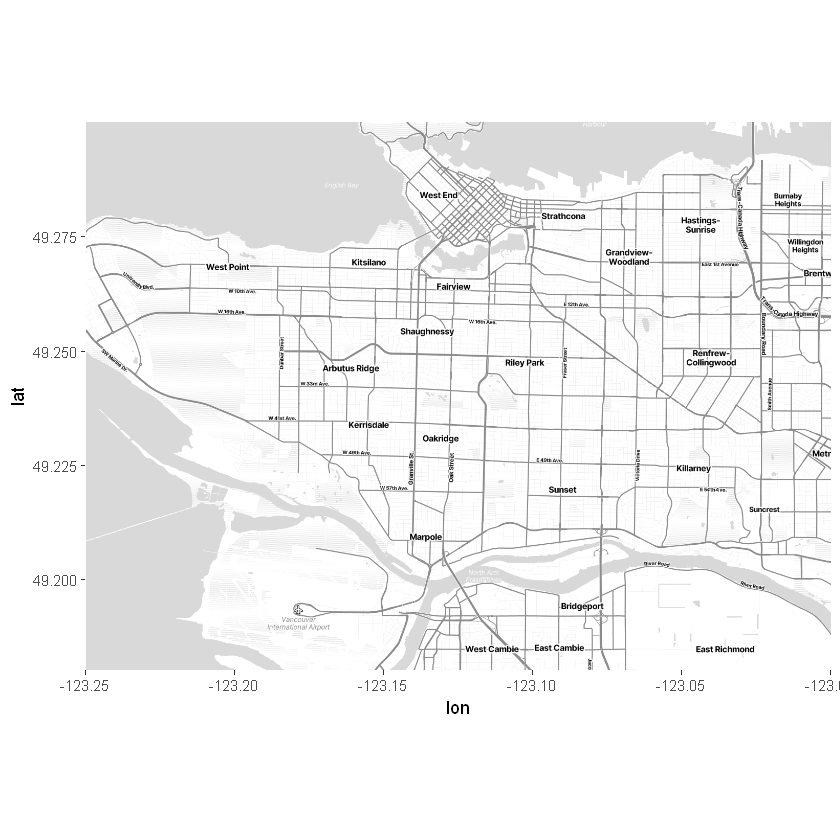

In [11]:
library(ggmap)

key = '953a00a4-1c69-45b1-a0e4-b3492abdf92b'

register_stadiamaps(key, write = FALSE)

bbox <- c(left = -123.25, bottom = 49.18, right = -123.0, top = 49.3)

base <- get_stadiamap(bbox = bbox, zoom = 13, maptype = "stamen_toner_lite", filetype = "svg")
ggmap(base)

Coordinate system already present. Adding new coordinate system, which will
replace the existing one.


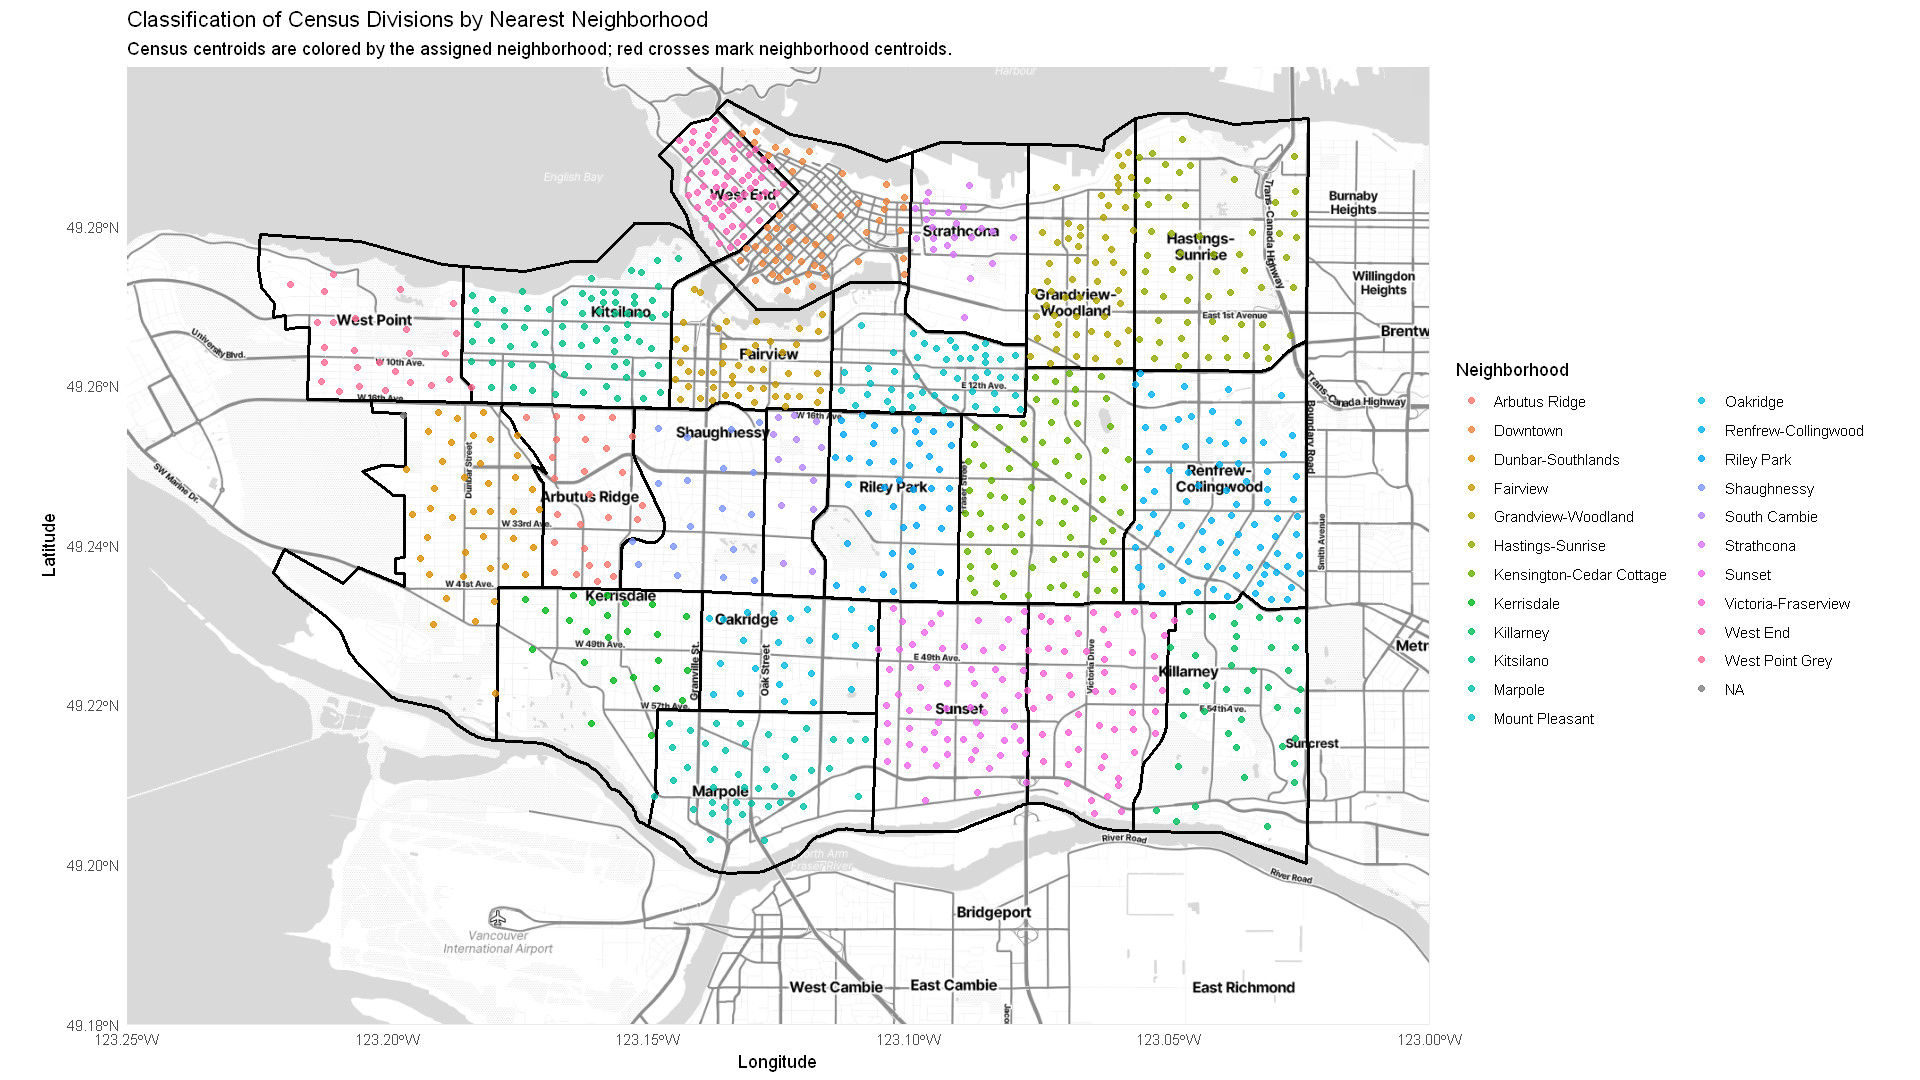

In [12]:
census2016_centroids <- census2016_centroids %>%
  mutate(neighborhood = census2016$neighborhood)

neighborhood_valid <- st_transform(neighborhood_valid, 4326)
census2016_centroids <- st_transform(census2016_centroids, 4326)

options(repr.plot.width = 16, repr.plot.height = 9)

# Create the plot of neighborhood
ggmap(base) +
  geom_sf(data = neighborhood_valid, inherit.aes = FALSE, fill = NA, color = "black", lwd = 1) +
  geom_sf(data = census2016_centroids,inherit.aes = FALSE, aes(color = neighborhood), size = 1.5, alpha = 0.8) +
  coord_sf(crs = st_crs(4326)) +
  labs(title = "Classification of Census Divisions by Nearest Neighborhood",
       subtitle = "Census centroids are colored by the assigned neighborhood; red crosses mark neighborhood centroids.",
       color = "Neighborhood",
       x = "Longitude", y = "Latitude") +
  theme_minimal()

In [13]:
census2016_panel <- merge(census2016, crime_trend_complete, by = "name")|>
    arrange(year, month)|>
    glimpse()

Rows: 238,320
Columns: 23
$ name                 <chr> "59150307", "59150307", "59150308", "59150308", "…
$ households           <int> 254, 254, 203, 203, 269, 269, 283, 283, 181, 181,…
$ dwellings            <int> 273, 273, 223, 223, 299, 299, 310, 310, 199, 199,…
$ population           <int> 632, 632, 501, 501, 745, 745, 536, 536, 532, 532,…
$ population_density   <dbl> 2110.9, 2110.9, 4575.3, 4575.3, 6663.7, 6663.7, 4…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.29926, 0.10956, 0.10956, 0.11190, 0.11…
$ age                  <int> 630, 630, 500, 500, 745, 745, 540, 540, 530, 530,…
$ income               <dbl> 0.90965, 0.90965, 0.93611, 0.93611, 0.84736, 0.84…
$ immigrant_prop       <dbl> 0.2610759, 0.2610759, 0.2894212, 0.2894212, 0.355…
$ university_prop      <dbl> 0.3085443, 0.3085443, 0.2794411, 0.2794411, 0.315…
$ school_index         <dbl> 1.074675, 1.074675, 1.252273, 1.252273, 1.426336,…
$ light_index 

In [14]:
census2016_2021_panel <- census2016_panel %>%
  left_join(census2021_clean, by = "name", suffix = c("", ".new")) |>
  mutate(
    # For each variable, if the date is on or after 2019-01-01, use the new (2021) data; otherwise keep the original
    households = if_else(date >= as.Date("2019-01-01"), households.new, households),
    dwellings = if_else(date >= as.Date("2019-01-01"), dwellings.new, dwellings),
    population = if_else(date >= as.Date("2019-01-01"), population.new, population),
    population_density = if_else(date >= as.Date("2019-01-01"), population_density.new, population_density),
    area_sq_km = if_else(date >= as.Date("2019-01-01"), area_sq_km.new, area_sq_km),
    age = if_else(date >= as.Date("2019-01-01"), age.new, age),
    income = if_else(date >= as.Date("2019-01-01"), income.new, income),
    immigrant_prop = if_else(date >= as.Date("2019-01-01"), immigrant_prop.new, immigrant_prop),
    university_prop = if_else(date >= as.Date("2019-01-01"), university_prop.new, university_prop)
  ) |>
  select(-ends_with(".new"))|>
  glimpse()


Rows: 238,320
Columns: 23
$ name                 <chr> "59150307", "59150307", "59150308", "59150308", "…
$ households           <dbl> 254, 254, 203, 203, 269, 269, 283, 283, 181, 181,…
$ dwellings            <dbl> 273, 273, 223, 223, 299, 299, 310, 310, 199, 199,…
$ population           <dbl> 632, 632, 501, 501, 745, 745, 536, 536, 532, 532,…
$ population_density   <dbl> 2110.9, 2110.9, 4575.3, 4575.3, 6663.7, 6663.7, 4…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.29926, 0.10956, 0.10956, 0.11190, 0.11…
$ age                  <dbl> 630, 630, 500, 500, 745, 745, 540, 540, 530, 530,…
$ income               <dbl> 0.90965, 0.90965, 0.93611, 0.93611, 0.84736, 0.84…
$ immigrant_prop       <dbl> 0.2610759, 0.2610759, 0.2894212, 0.2894212, 0.355…
$ university_prop      <dbl> 0.3085443, 0.3085443, 0.2794411, 0.2794411, 0.315…
$ school_index         <dbl> 1.074675, 1.074675, 1.252273, 1.252273, 1.426336,…
$ light_index 

In [15]:
select <- dplyr::select

In [16]:


# Read in the NASA NTL data
ntl_data <- read_csv("NTL_data/NASA_ntl_2012_2024_monthly.csv")|>
    filter(!is.na(ntl_mean))|>
    select(!c(population, population_density))|>
    mutate(date = as.Date(paste0(date, "-01")))|>
    glimpse()

ntl_data$name <- as.character(ntl_data$name)

Rows: 154908 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): date
dbl (7): name, population, population_density, ntl_mean, n_pixels, n_non_na_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 141,792
Columns: 6
$ name               <dbl> 59150307, 59150309, 59150311, 59150313, 59150328, 5…
$ ntl_mean           <dbl> 3.710000, 3.020000, 3.971038, 4.609642, 4.880000, 4…
$ n_pixels           <dbl> 5, 4, 4, 4, 3, 8, 4, 4, 4, 4, 4, 4, 6, 3, 3, 3, 4, …
$ n_non_na_pixels    <dbl> 1, 1, 2, 2, 1, 4, 4, 3, 4, 4, 4, 4, 6, 3, 3, 3, 4, …
$ prop_non_na_pixels <dbl> 0.2000000, 0.2500000, 0.5000000, 0.5000000, 0.33333…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


In [17]:
sum(census2016_2021_panel$crime_count == 0)

[1] 133617

In [18]:
# Merge 2 dataframes
census2016_2021_panel <- census2016_2021_panel|>
    left_join(ntl_data, by = c("name", "date"))|>
    glimpse()

Rows: 238,320
Columns: 27
$ name                 <chr> "59150307", "59150307", "59150308", "59150308", "…
$ households           <dbl> 254, 254, 203, 203, 269, 269, 283, 283, 181, 181,…
$ dwellings            <dbl> 273, 273, 223, 223, 299, 299, 310, 310, 199, 199,…
$ population           <dbl> 632, 632, 501, 501, 745, 745, 536, 536, 532, 532,…
$ population_density   <dbl> 2110.9, 2110.9, 4575.3, 4575.3, 6663.7, 6663.7, 4…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.29926, 0.10956, 0.10956, 0.11190, 0.11…
$ age                  <dbl> 630, 630, 500, 500, 745, 745, 540, 540, 530, 530,…
$ income               <dbl> 0.90965, 0.90965, 0.93611, 0.93611, 0.84736, 0.84…
$ immigrant_prop       <dbl> 0.2610759, 0.2610759, 0.2894212, 0.2894212, 0.355…
$ university_prop      <dbl> 0.3085443, 0.3085443, 0.2794411, 0.2794411, 0.315…
$ school_index         <dbl> 1.074675, 1.074675, 1.252273, 1.252273, 1.426336,…
$ light_index 

In [19]:
crime_summary <- census2016_2021_panel|>
    st_drop_geometry()|>
    summarise(mean = mean(crime_count),
    variance = var(crime_count),
    min = min(crime_count),
    max = max(crime_count))

crime_summary

mean,variance,min,max
<dbl>,<dbl>,<int>,<int>
1.249324,22.24452,0,198


Since the crime data is highly volatile and affected by a lot of empty bins, and apparently it has a much larger variance comparing to its mean value. So instead of using the raw variable, we would employ a negative binomial regression to find its expected value given fixed effects of year, month, division, time_category, and we are using population density as an offset variable. 

In [20]:
census2016_2021_panel <- census2016_2021_panel|>
    mutate(is_downtown = ifelse(neighborhood == "Downtown", 1, 0))|>
    glimpse()

Rows: 238,320
Columns: 28
$ name                 <chr> "59150307", "59150307", "59150308", "59150308", "…
$ households           <dbl> 254, 254, 203, 203, 269, 269, 283, 283, 181, 181,…
$ dwellings            <dbl> 273, 273, 223, 223, 299, 299, 310, 310, 199, 199,…
$ population           <dbl> 632, 632, 501, 501, 745, 745, 536, 536, 532, 532,…
$ population_density   <dbl> 2110.9, 2110.9, 4575.3, 4575.3, 6663.7, 6663.7, 4…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.29926, 0.10956, 0.10956, 0.11190, 0.11…
$ age                  <dbl> 630, 630, 500, 500, 745, 745, 540, 540, 530, 530,…
$ income               <dbl> 0.90965, 0.90965, 0.93611, 0.93611, 0.84736, 0.84…
$ immigrant_prop       <dbl> 0.2610759, 0.2610759, 0.2894212, 0.2894212, 0.355…
$ university_prop      <dbl> 0.3085443, 0.3085443, 0.2794411, 0.2794411, 0.315…
$ school_index         <dbl> 1.074675, 1.074675, 1.252273, 1.252273, 1.426336,…
$ light_index 

In [21]:
census2016_2021_panel <- census2016_2021_panel|>
    filter(!is.na(population_density), !is.na(year), !is.na(month), !is.na(time_category))|>
    glimpse()

Rows: 235,080
Columns: 28
$ name                 <chr> "59150307", "59150307", "59150308", "59150308", "…
$ households           <dbl> 254, 254, 203, 203, 269, 269, 283, 283, 181, 181,…
$ dwellings            <dbl> 273, 273, 223, 223, 299, 299, 310, 310, 199, 199,…
$ population           <dbl> 632, 632, 501, 501, 745, 745, 536, 536, 532, 532,…
$ population_density   <dbl> 2110.9, 2110.9, 4575.3, 4575.3, 6663.7, 6663.7, 4…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.29926, 0.10956, 0.10956, 0.11190, 0.11…
$ age                  <dbl> 630, 630, 500, 500, 745, 745, 540, 540, 530, 530,…
$ income               <dbl> 0.90965, 0.90965, 0.93611, 0.93611, 0.84736, 0.84…
$ immigrant_prop       <dbl> 0.2610759, 0.2610759, 0.2894212, 0.2894212, 0.355…
$ university_prop      <dbl> 0.3085443, 0.3085443, 0.2794411, 0.2794411, 0.315…
$ school_index         <dbl> 1.074675, 1.074675, 1.252273, 1.252273, 1.426336,…
$ light_index 

In [22]:
# Coverting fixed effects as factors
census2016_2021_panel$name <- as.factor(census2016_2021_panel$name)
census2016_2021_panel$year <- as.factor(census2016_2021_panel$year)
census2016_2021_panel$month <- as.factor(census2016_2021_panel$month)
census2016_2021_panel$time_category <- as.factor(census2016_2021_panel$time_category)
census2016_2021_panel$neighborhood <- as.factor(census2016_2021_panel$neighborhood)

In [23]:
# Load necessary packages
library(MASS)

### 1. Fit different models

# 1.1 Poisson model (intercept only)
fit_pois <- glm(crime_count ~ 1,
                data = crime_trend_complete,
                family = poisson())

# 1.2 Negative Binomial model
fit_nb <- glm.nb(crime_count ~ 1,
                 data = crime_trend_complete)

# 1.3 Zero-Inflated Poisson (ZIP) model
# Format crime_count ~ 1 | 1 means count part and zero-inflation part only include intercepts
fit_zip <- zeroinfl(crime_count ~ 1 | 1,
                    data = crime_trend_complete,
                    dist = "poisson")

# 1.4 Zero-Inflated Negative Binomial (ZINB) model
fit_zinb <- zeroinfl(crime_count ~ 1 | 1,
                     data = crime_trend_complete,
                     dist = "negbin")

# 1.5 Hurdle Poisson model
fit_hurdle_pois <- hurdle(crime_count ~ 1,
                          data = crime_trend_complete,
                          dist = "poisson")

# 1.6 Hurdle Negative Binomial model
fit_hurdle_nb <- hurdle(crime_count ~ 1,
                        data = crime_trend_complete,
                        dist = "negbin")

### 2. Model comparison
# We use AIC and BIC to evaluate the goodness of fit for each model

model_names <- c("Poisson", "NegBin", "ZIP", "ZINB", "Hurdle_Poisson", "Hurdle_NegBin")
aic_values <- c(AIC(fit_pois),
                AIC(fit_nb),
                AIC(fit_zip),
                AIC(fit_zinb),
                AIC(fit_hurdle_pois),
                AIC(fit_hurdle_nb))
bic_values <- c(BIC(fit_pois),
                BIC(fit_nb),
                BIC(fit_zip),
                BIC(fit_zinb),
                BIC(fit_hurdle_pois),
                BIC(fit_hurdle_nb))

model_comparison <- data.frame(Model = model_names,
                               AIC = aic_values,
                               BIC = bic_values)
print(model_comparison)

### 3. Non-nested model comparison: Vuong test
# Vuong test helps us compare zero-inflated models with their non-zero-inflated counterparts (e.g., ZIP vs Poisson, ZINB vs NegBin)
vuong_zip_pois   <- vuong(fit_zip, fit_pois)
vuong_zinb_nb    <- vuong(fit_zinb, fit_nb)
# We can also compare ZIP with Hurdle Poisson, and ZINB with Hurdle NB
vuong_zip_hurdle <- vuong(fit_zip, fit_hurdle_pois)
vuong_zinb_hurdle<- vuong(fit_zinb, fit_hurdle_nb)

cat("Vuong test: ZIP vs Poisson\n")
print(vuong_zip_pois)

cat("Vuong test: ZINB vs Negative Binomial\n")
print(vuong_zinb_nb)

cat("Vuong test: ZIP vs Hurdle Poisson\n")
print(vuong_zip_hurdle)

cat("Vuong test: ZINB vs Hurdle Negative Binomial\n")
print(vuong_zinb_hurdle)

### 4. View summaries for each model
cat("\nPoisson model summary:\n")
summary(fit_pois)

cat("\nNegative Binomial model summary:\n")
summary(fit_nb)

cat("\nZero-Inflated Poisson model summary (ZIP):\n")
summary(fit_zip)

cat("\nZero-Inflated Negative Binomial model summary (ZINB):\n")
summary(fit_zinb)

cat("\nHurdle Poisson model summary:\n")
summary(fit_hurdle_pois)

cat("\nHurdle Negative Binomial model summary:\n")
summary(fit_hurdle_nb)


Warning message:
"package 'MASS' was built under R version 4.4.2"

Attaching package: 'MASS'


The following object is masked _by_ '.GlobalEnv':

    select


The following object is masked from 'package:patchwork':

    area


The following object is masked from 'package:dplyr':

    select




           Model       AIC       BIC
1        Poisson 1203647.7 1203658.1
2         NegBin  688925.8  688946.6
3            ZIP 1026842.7 1026863.5
4           ZINB  688927.9  688959.0
5 Hurdle_Poisson 1026842.7 1026863.5
6  Hurdle_NegBin  674058.0  674089.1
NA or numerical zeros or ones encountered in fitted probabilities
dropping these 2 cases, but proceed with caution
Vuong Non-Nested Hypothesis Test-Statistic: 
(test-statistic is asymptotically distributed N(0,1) under the
 null that the models are indistinguishible)
-------------------------------------------------------------
              Vuong z-statistic             H_A    p-value
Raw                    53.71270 model1 > model2 < 2.22e-16
AIC-corrected          53.71209 model1 > model2 < 2.22e-16
BIC-corrected          53.70893 model1 > model2 < 2.22e-16
Vuong Non-Nested Hypothesis Test-Statistic: 
(test-statistic is asymptotically distributed N(0,1) under the
 null that the models are indistinguishible)
----------------------


Call:
glm(formula = crime_count ~ 1, family = poisson(), data = crime_trend_complete)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) 0.222603   0.001833   121.5   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 940979  on 238319  degrees of freedom
Residual deviance: 940979  on 238319  degrees of freedom
AIC: 1203648

Number of Fisher Scoring iterations: 6



Negative Binomial model summary:



Call:
glm.nb(formula = crime_count ~ 1, data = crime_trend_complete, 
    init.theta = 0.3458684184, link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) 0.222603   0.003936   56.56   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.3459) family taken to be 1)

    Null deviance: 199886  on 238319  degrees of freedom
Residual deviance: 199886  on 238319  degrees of freedom
AIC: 688926

Number of Fisher Scoring iterations: 1


              Theta:  0.34587 
          Std. Err.:  0.00164 

 2 x log-likelihood:  -688921.85000 

...


Call:
zeroinfl(formula = crime_count ~ 1 | 1, data = crime_trend_complete, 
    dist = "negbin")

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.5205 -0.5205 -0.5205 -0.1039 81.9651 

Count model coefficients (negbin with log link):
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  0.222600   0.003936   56.56   <2e-16 ***
Log(theta)  -1.061696   0.004754 -223.34   <2e-16 ***

Zero-inflation model coefficients (binomial with logit link):
            Estimate Std. Error z value Pr(>|z|)
(Intercept)  -13.626      8.443  -1.614    0.107
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1 

Theta = 0.3459 
Number of iterations in BFGS optimization: 23 
Log-likelihood: -3.445e+05 on 3 Df


Hurdle Poisson model summary:



Call:
hurdle(formula = crime_count ~ 1, data = crime_trend_complete, dist = "poisson")

Pearson residuals:
     Min       1Q   Median       3Q      Max 
 -0.7228  -0.7228  -0.7228  -0.1442 113.8244 

Count model coefficients (truncated poisson with log link):
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) 0.971124   0.002052   473.1   <2e-16 ***
Zero hurdle model coefficients (binomial with logit link):
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -0.243850   0.004127  -59.08   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1 

Number of iterations in BFGS optimization: 9 
Log-likelihood: -5.134e+05 on 2 Df


Hurdle Negative Binomial model summary:



Call:
hurdle(formula = crime_count ~ 1, data = crime_trend_complete, dist = "negbin")

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.5034 -0.5034 -0.5034 -0.1005 79.2849 

Count model coefficients (truncated negbin with log link):
            Estimate Std. Error z value Pr(>|z|)  
(Intercept)  -12.237      7.636  -1.603   0.1090  
Log(theta)   -13.881      7.636  -1.818   0.0691 .
Zero hurdle model coefficients (binomial with logit link):
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -0.243850   0.004127  -59.08   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1 

Theta: count = 0
Number of iterations in BFGS optimization: 17 
Log-likelihood: -3.37e+05 on 3 Df

Based on the result above, we choose to use a hurdle negative binomial regression to account for an expected crime.

In [23]:
# Making necessary changes to the data
census2016_2021_panel_night <- census2016_2021_panel|>
    filter(time_category == "night")|>
    mutate(year = as.factor(year))|>
    mutate(neighborhood = as.factor(neighborhood))|>
    mutate(income = as.numeric(income), immigrant_prop = as.numeric(immigrant_prop), university_prop = as.numeric(university_prop))|>
    mutate(is_downtown = ifelse(is.na(is_downtown), 0, is_downtown))|>
    filter(!is.na(income), !is.na(university_prop), !is.na(immigrant_prop))|>
    dplyr::select(-time_category)|>
    st_drop_geometry()|>
    glimpse()

Rows: 117,000
Columns: 26
$ name                 <fct> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ households           <dbl> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <dbl> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index 

In [24]:
# Adding day crime as a control
census2016_2021_panel_day <- census2016_2021_panel|>
    filter(time_category == "day")|>
    rename(day_crime_count = crime_count)|>
    dplyr::select(name, date, day_crime_count)|>
    st_drop_geometry()

census2016_2021_panel_night <- census2016_2021_panel_night|>
    left_join(census2016_2021_panel_day, by = c("name", "date"))|>
    mutate(day_crime_count = ifelse(is.na(day_crime_count), 0, day_crime_count))|>
    glimpse()

Rows: 117,000
Columns: 27
$ name                 <fct> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ households           <dbl> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <dbl> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index 

In [ ]:
# Implementing the hurdle negative binomial regression
model_hurdle_nb <- hurdle(crime_count ~ name + year + month + offset(log(population_density)),
                            data = census2016_2021_panel_night,
                            dist = "negbin")

# Summarize the fitted model to inspect the results
summary(model_hurdle_nb)

In [28]:
census2016_2021_panel_night$expected_crime <- predict(model_hurdle_nb, type = "response")

glimpse(census2016_2021_panel_night)

Rows: 117,000
Columns: 28
$ name                 <fct> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ households           <dbl> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <dbl> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index 

In [ ]:
# Implementing the hurdle negative binomial regression
model_hurdle_nb_day <- hurdle(day_crime_count ~ name + year + month + offset(log(population_density)),
                            data = census2016_2021_panel_night,
                            dist = "negbin")

# Summarize the fitted model to inspect the results
summary(model_hurdle_nb_day)

In [30]:
census2016_2021_panel_night$expected_day_crime <- predict(model_hurdle_nb_day, type = "response")

glimpse(census2016_2021_panel_night)

Rows: 117,000
Columns: 29
$ name                 <fct> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ households           <dbl> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <dbl> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index 

In [31]:
summary(census2016_2021_panel_night$expected_crime)
summary(census2016_2021_panel_night$expected_day_crime)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
  0.08399   0.50293   0.73476   1.38060   1.14057 128.50900 

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
  0.02545   0.21987   0.34415   0.91956   0.61806 128.44451 

`geom_smooth()` using formula = 'y ~ x'


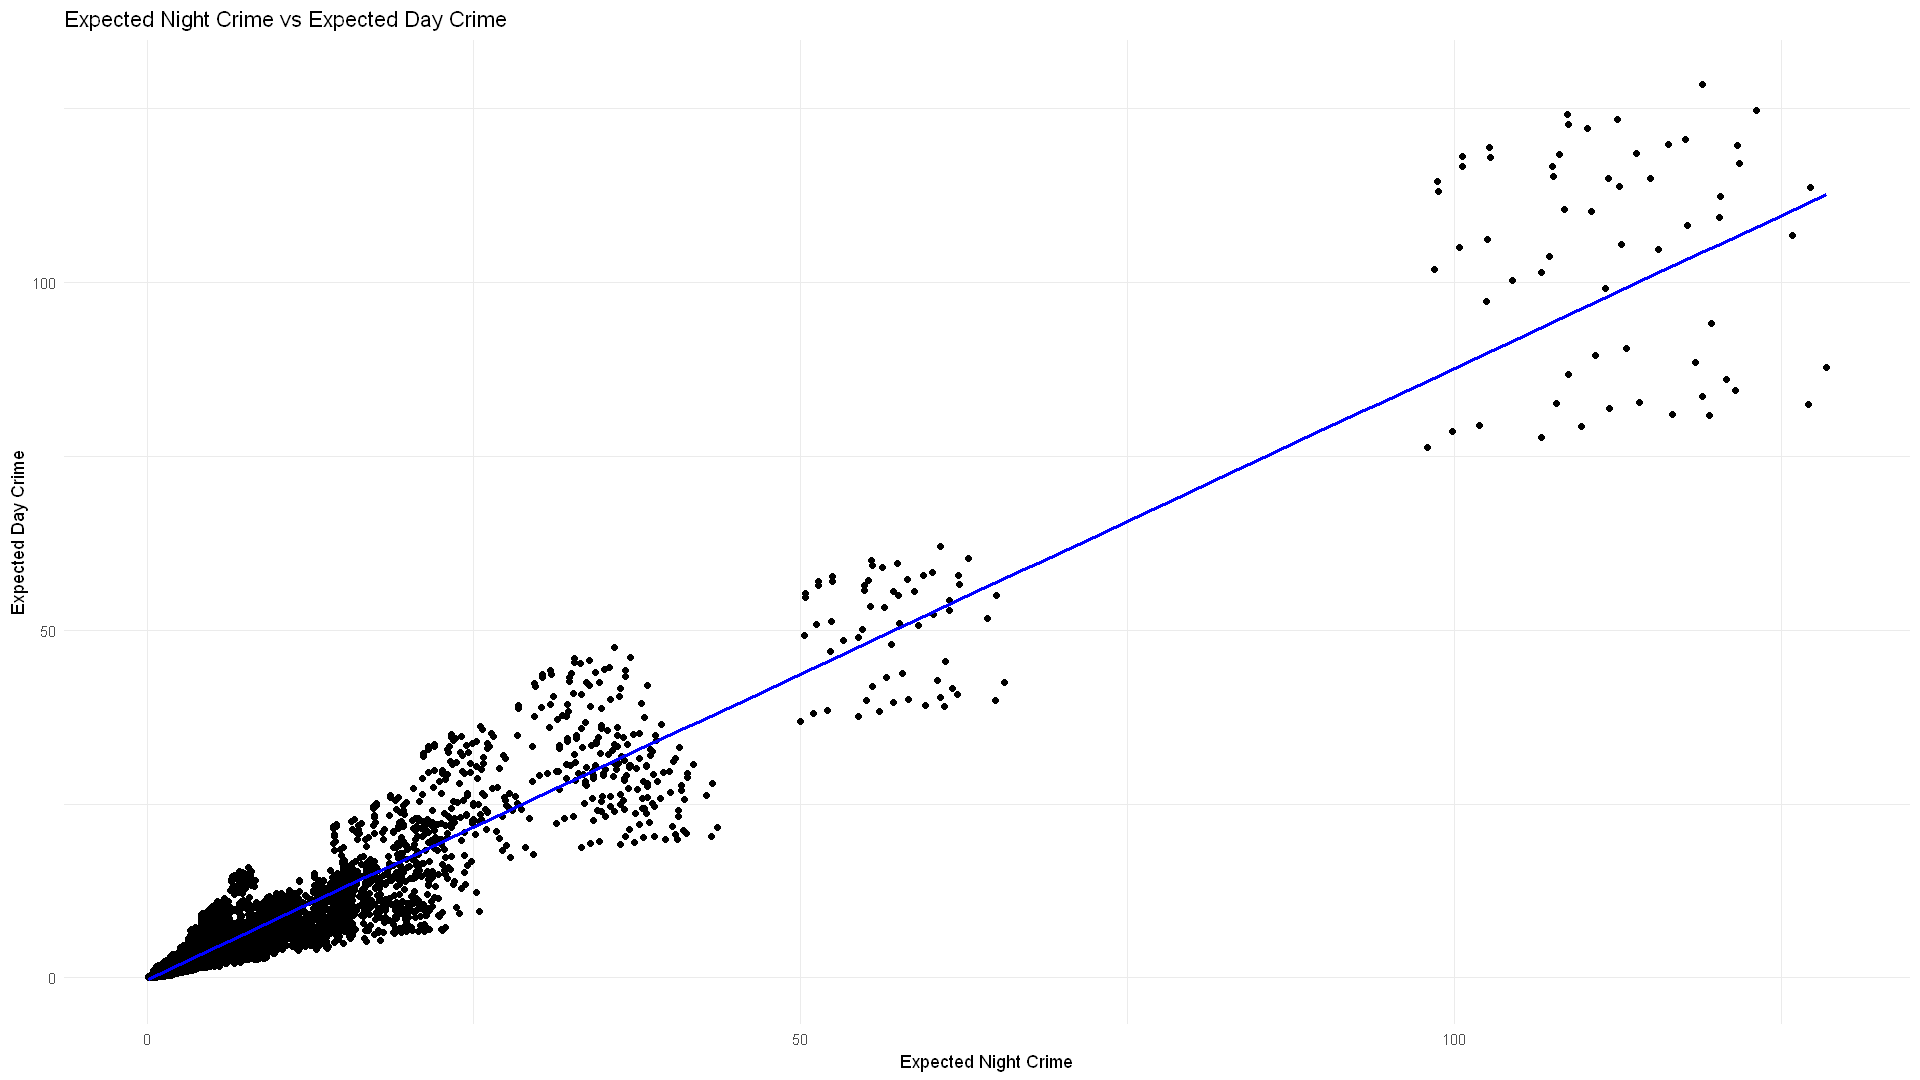

In [34]:
ggplot(data = census2016_2021_panel_night, aes(x = expected_crime, y = expected_day_crime)) +
  geom_point() +
  labs(title = "Expected Night Crime vs Expected Day Crime",
       x = "Expected Night Crime",
       y = "Expected Day Crime") +
  geom_smooth(method = "lm", se = FALSE, color = "blue") +
  theme_minimal()

In [35]:
# Read in data for electric price index
electric_index <- read_csv("electric_price_index.csv")|>
    dplyr::select(REF_DATE, Index, VALUE)|>
    filter(Index == "Electric power selling price under 5000kw")|>
    mutate(date = as.Date(paste0(REF_DATE, "-01")))|>
    rename("electric_index" = "VALUE")|>
    dplyr::select(date, electric_index)|>
    glimpse()

Rows: 264 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): REF_DATE, GEO, DGUID, Index, UOM, SCALAR_FACTOR, VECTOR
dbl (5): UOM_ID, SCALAR_ID, COORDINATE, VALUE, DECIMALS
lgl (3): STATUS, SYMBOL, TERMINATED

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 132
Columns: 2
$ date           <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 2014-0…
$ electric_index <dbl> 94.8, 94.8, 94.8, 101.7, 101.7, 101.7, 101.7, 101.7, 10…


In [36]:
census2016_2021_panel_night <- census2016_2021_panel_night|>
    left_join(electric_index, by = "date")|>
    glimpse()

Rows: 117,000
Columns: 30
$ name                 <fct> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ households           <dbl> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <dbl> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ university_prop      <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index 

In [ ]:
# Save the data so we can start from here next time
census2016_2021_panel_night <- census2016_2021_panel_night|>
    select(-c(households, dwellings, region))

write_csv(census2016_2021_panel_night, "census2016_2021_panel.csv")

ERROR: [1m[33mError[39m in `select()`:[22m
[33m![39m Can't select columns that don't exist.
[31m✖[39m Column `households` doesn't exist.


#### Wrapping neighborhood data

In [45]:
# Generate the dataset on 22 neighborhood
neighborhood2016_2021_panel <- census2016_2021_panel|>
    st_drop_geometry()|>
    filter(name != "59153586") |>  # Remove Stanley Park
    mutate(income = as.double(income)) |>
    filter(!is.na(income)) |>
    # Create separate month and year columns
    group_by(neighborhood, year, month, time_category) |>
    summarise(
        population = sum(population),
        area_sq_km = sum(area_sq_km),
        population_density = population / area_sq_km,
        income = mean(income),
        crime_count = sum(crime_count),
        electric_index = mean(electric_index, na.rm = TRUE),
        .groups = "drop"
    ) |>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Warning message:
"There were 5520 warnings in `summarise()`.
The first warning was:
ℹ In argument: `electric_index = mean(electric_index, na.rm = TRUE)`.
ℹ In group 1: `neighborhood = Arbutus Ridge`, `year = 2014`, `month = 1`,
  `time_category = day`.
Caused by warning in `mean.default()`:
! argument is not numeric or logical: returning NA
ℹ Run `dplyr::last_dplyr_warnings()` to see the 5519 remaining warnings."


Rows: 5,520
Columns: 11
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, …
$ time_category      <fct> day, night, day, night, day, night, day, night, day…
$ population         <dbl> 14726, 14726, 14726, 14726, 14726, 14726, 14726, 14…
$ area_sq_km         <dbl> 3.56967, 3.56967, 3.56967, 3.56967, 3.56967, 3.5696…
$ population_density <dbl> 4125.311, 4125.311, 4125.311, 4125.311, 4125.311, 4…
$ income             <dbl> 0.8086515, 0.8086515, 0.8086515, 0.8086515, 0.80865…
$ crime_count        <int> 10, 17, 3, 19, 8, 11, 9, 22, 11, 24, 11, 31, 11, 17…
$ electric_index     <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ date               <date> 2014-01-01, 2014-01-01, 2014-02-01, 2014-02-01, 20…


In [46]:
neighborhood_ntl <- read_csv("NTL_data/22_ntl_2012_2024_monthly.csv")|>
    rename("neighborhood" = "name")|>
    filter(!is.na(ntl_mean))|>
    mutate(date = as.Date(paste0(date, "-01")))|>
    dplyr::select(!geo_point_2d)|>
    glimpse()

Rows: 3432 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): name, geo_point_2d, date
dbl (4): ntl_mean, n_pixels, n_non_na_pixels, prop_non_na_pixels

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3,146
Columns: 6
$ neighborhood       <chr> "Downtown", "Hastings-Sunrise", "Kerrisdale", "Marp…
$ ntl_mean           <dbl> 15.101049, 3.424347, 2.195419, 4.155951, 3.277409, …
$ n_pixels           <dbl> 54, 71, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 69,…
$ n_non_na_pixels    <dbl> 54, 53, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 45,…
$ prop_non_na_pixels <dbl> 1.0000000, 0.7464789, 1.0000000, 1.0000000, 1.00000…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


In [47]:
neighborhood2016_2021_panel <- neighborhood2016_2021_panel|>
    left_join(neighborhood_ntl, by = c("neighborhood", "date"))|>
    mutate(is_downtown = ifelse(neighborhood == "Downtown", 1, 0))|>
    filter(!is.na(neighborhood))|>
    glimpse()

Rows: 5,280
Columns: 16
$ neighborhood       <chr> "Arbutus Ridge", "Arbutus Ridge", "Arbutus Ridge", …
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, …
$ time_category      <fct> day, night, day, night, day, night, day, night, day…
$ population         <dbl> 14726, 14726, 14726, 14726, 14726, 14726, 14726, 14…
$ area_sq_km         <dbl> 3.56967, 3.56967, 3.56967, 3.56967, 3.56967, 3.5696…
$ population_density <dbl> 4125.311, 4125.311, 4125.311, 4125.311, 4125.311, 4…
$ income             <dbl> 0.8086515, 0.8086515, 0.8086515, 0.8086515, 0.80865…
$ crime_count        <int> 10, 17, 3, 19, 8, 11, 9, 22, 11, 24, 11, 31, 11, 17…
$ electric_index     <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ date               <date> 2014-01-01, 2014-01-01, 2014-02-01, 2014-02-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.041108, 3.063007, 3.063007, 3.580293, 3…
$ n_pixels      

In [48]:
neighborhood_crime_summary <- neighborhood2016_2021_panel|>
    group_by(time_category)|>
    summarise(mean = mean(crime_count),
    variance = var(crime_count),
    min = min(crime_count),
    max = max(crime_count))

neighborhood_crime_summary

time_category,mean,variance,min,max
<fct>,<dbl>,<dbl>,<int>,<int>
day,39.99470,3414.761,0,523
night,60.56591,5733.233,3,668


In [49]:
write_csv(neighborhood2016_2021_panel, "neighborhood2016_2021_panel.csv")

### Panel Fixed Effect Model

#### Explorations on 989 Census Divisions

With the data ready, we can run our first panel fixed effect model.

In [2]:
census2016_2021_panel_night <- read_csv("census2016_2021_panel.csv")

Rows: 117000 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): neighborhood
dbl  (25): name, population, population_density, area_sq_km, age, income, im...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
# A balancing table of census panel
covariates <- c("is_downtown", "electric_index", "income", "expected_day_crime",
                "population_density", "immigrant_prop", "university_prop", 
                "school_index", "bus_index", "cultural_space_index", 
                "mean_land_value")

# Here we assign "High" if above the median and "Low" otherwise.
census2016_2021_panel_night$treated <- ifelse(
  census2016_2021_panel_night$ntl_mean > median(census2016_2021_panel_night$ntl_mean, na.rm = TRUE), 
  "High", 
  "Low"
)

# Generate the balancing table using the CreateTableOne function.
bal_table <- CreateTableOne(vars = covariates, strata = "treated", 
                            data = census2016_2021_panel_night, test = TRUE)

# Print the table with standardized mean differences (SMD)
print(bal_table, smd = TRUE)

                                  Stratified by treated
                                   High                Low               p     
  n                                   53624              53625                 
  is_downtown (mean (SD))              0.10 (0.30)        0.00 (0.03)    <0.001
  electric_index (mean (SD))         115.39 (7.27)      114.81 (7.17)    <0.001
  income (mean (SD))                   0.73 (0.23)        0.90 (0.27)    <0.001
  expected_day_crime (mean (SD))       1.41 (4.62)        0.40 (0.70)    <0.001
  population_density (mean (SD))   13567.03 (11995.65) 6638.29 (5007.72) <0.001
  immigrant_prop (mean (SD))           0.38 (0.14)        0.45 (0.14)    <0.001
  university_prop (mean (SD))          0.18 (0.20)        0.18 (0.17)     0.002
  school_index (mean (SD))             2.75 (0.75)        2.49 (0.85)    <0.001
  bus_index (mean (SD))                3.14 (0.73)        2.68 (0.77)    <0.001
  cultural_space_index (mean (SD))     2.63 (0.98)        1.79 (

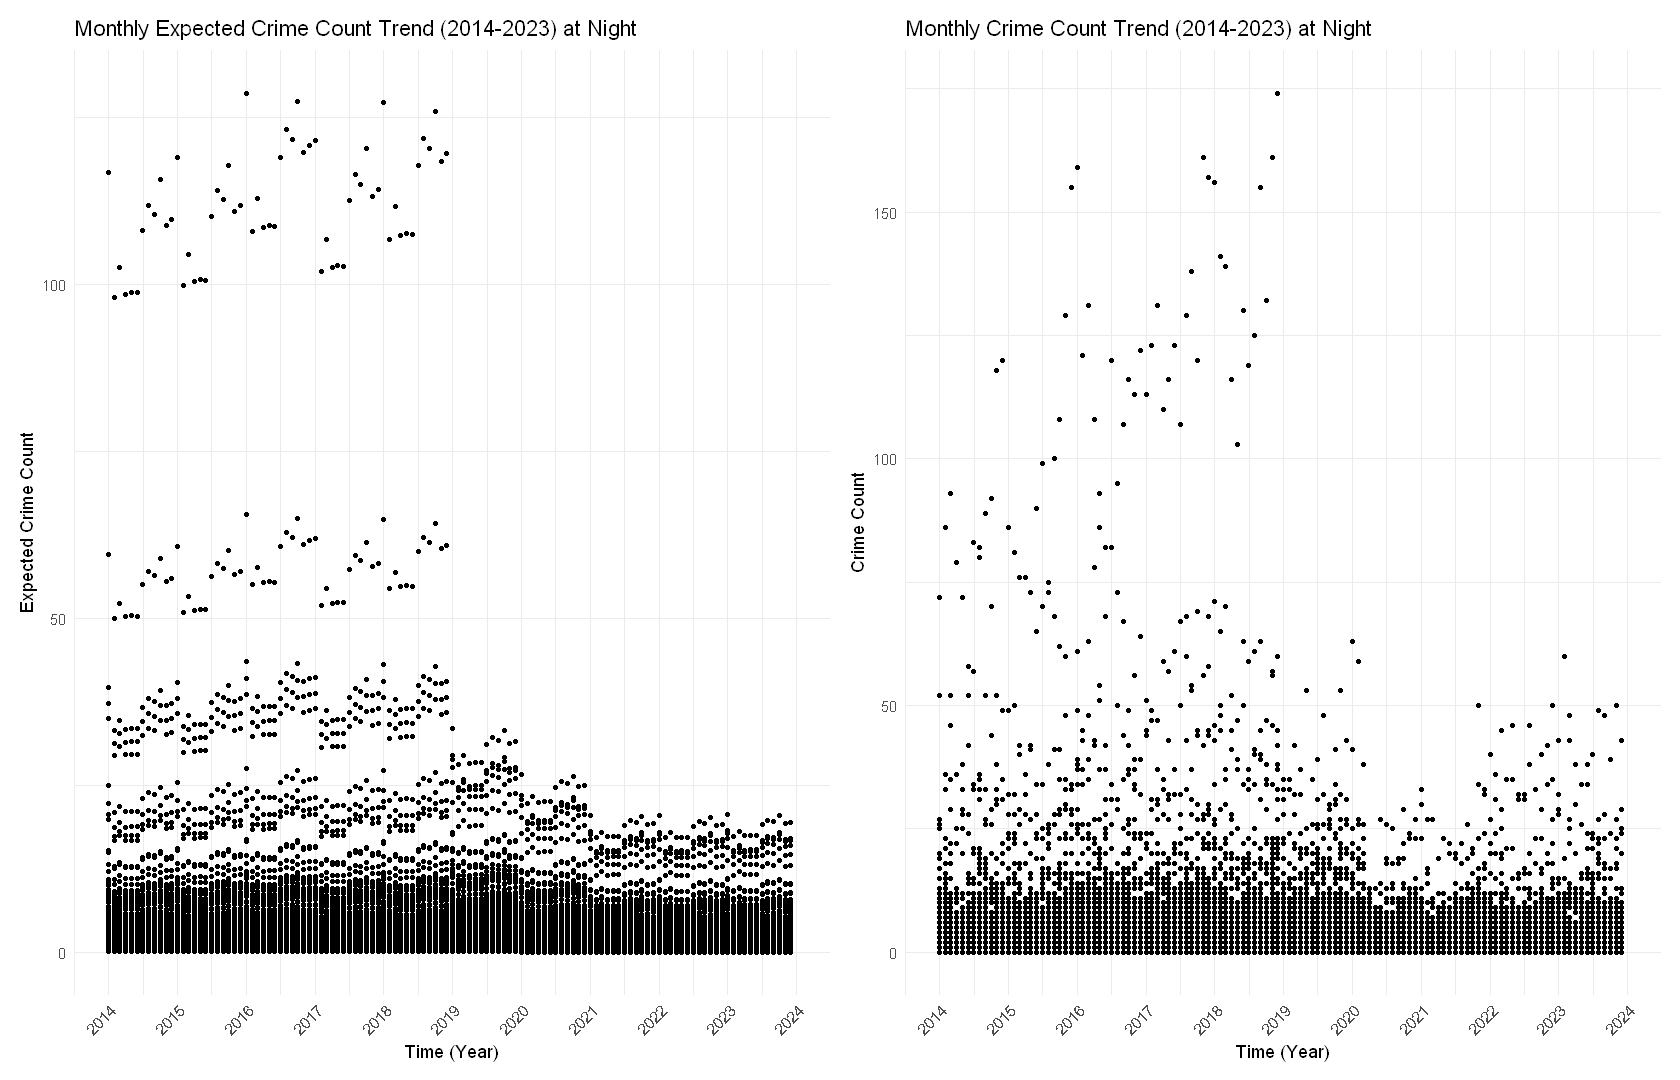

In [4]:
# Plot for expected crime count
options(repr.plot.width = 14, repr.plot.height = 9)

census_night_expected_dist <- ggplot(census2016_2021_panel_night, aes(x = date, y = expected_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2014-2023) at Night") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Plot for actual crime count
census_night_count_dist <- ggplot(census2016_2021_panel_night, aes(x = date, y = crime_count)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2014-2023) at Night") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Combine the two plots side by side
census_night_expected_dist + census_night_count_dist

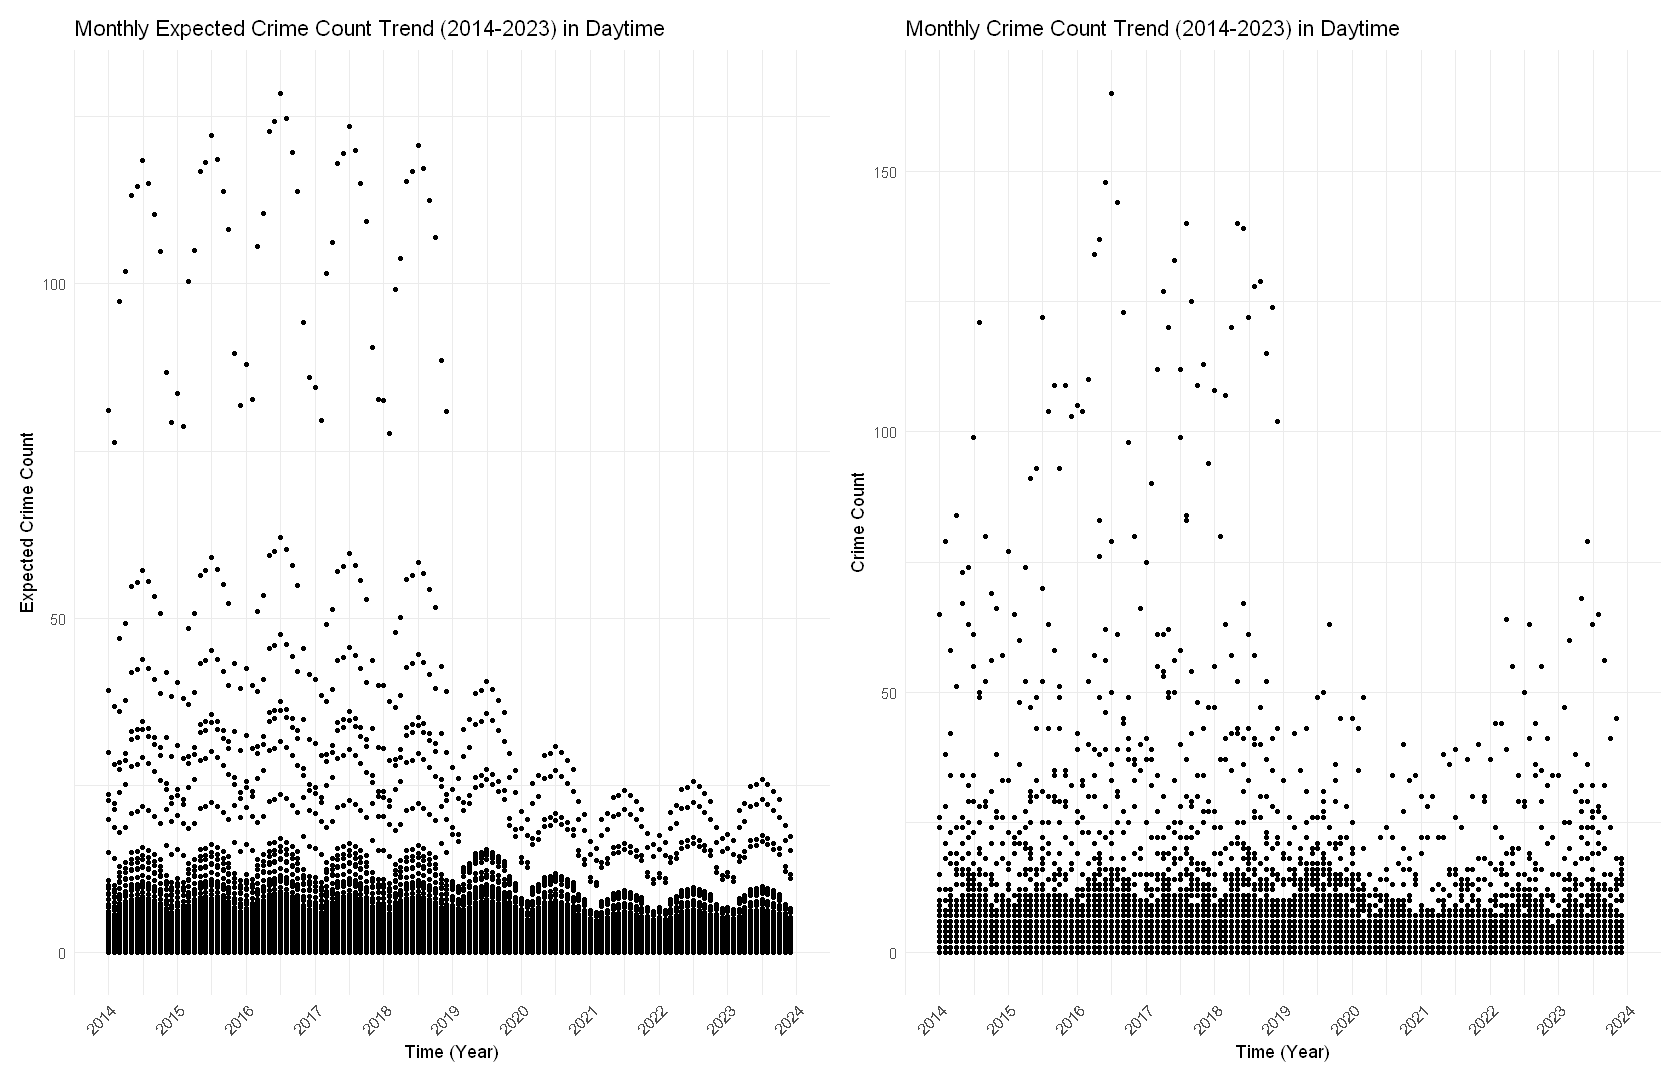

In [5]:
# Plot for expected crime count
options(repr.plot.width = 14, repr.plot.height = 9)

census_day_expected_dist <- ggplot(census2016_2021_panel_night, aes(x = date, y = expected_day_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2014-2023) in Daytime") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Plot for actual crime count
census_day_count_dist <- ggplot(census2016_2021_panel_night, aes(x = date, y = day_crime_count)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2014-2023) in Daytime") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Combine the two plots side by side
census_day_expected_dist + census_day_count_dist

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 9751 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 9751 rows containing missing values or values outside the scale range
(`geom_point()`)."


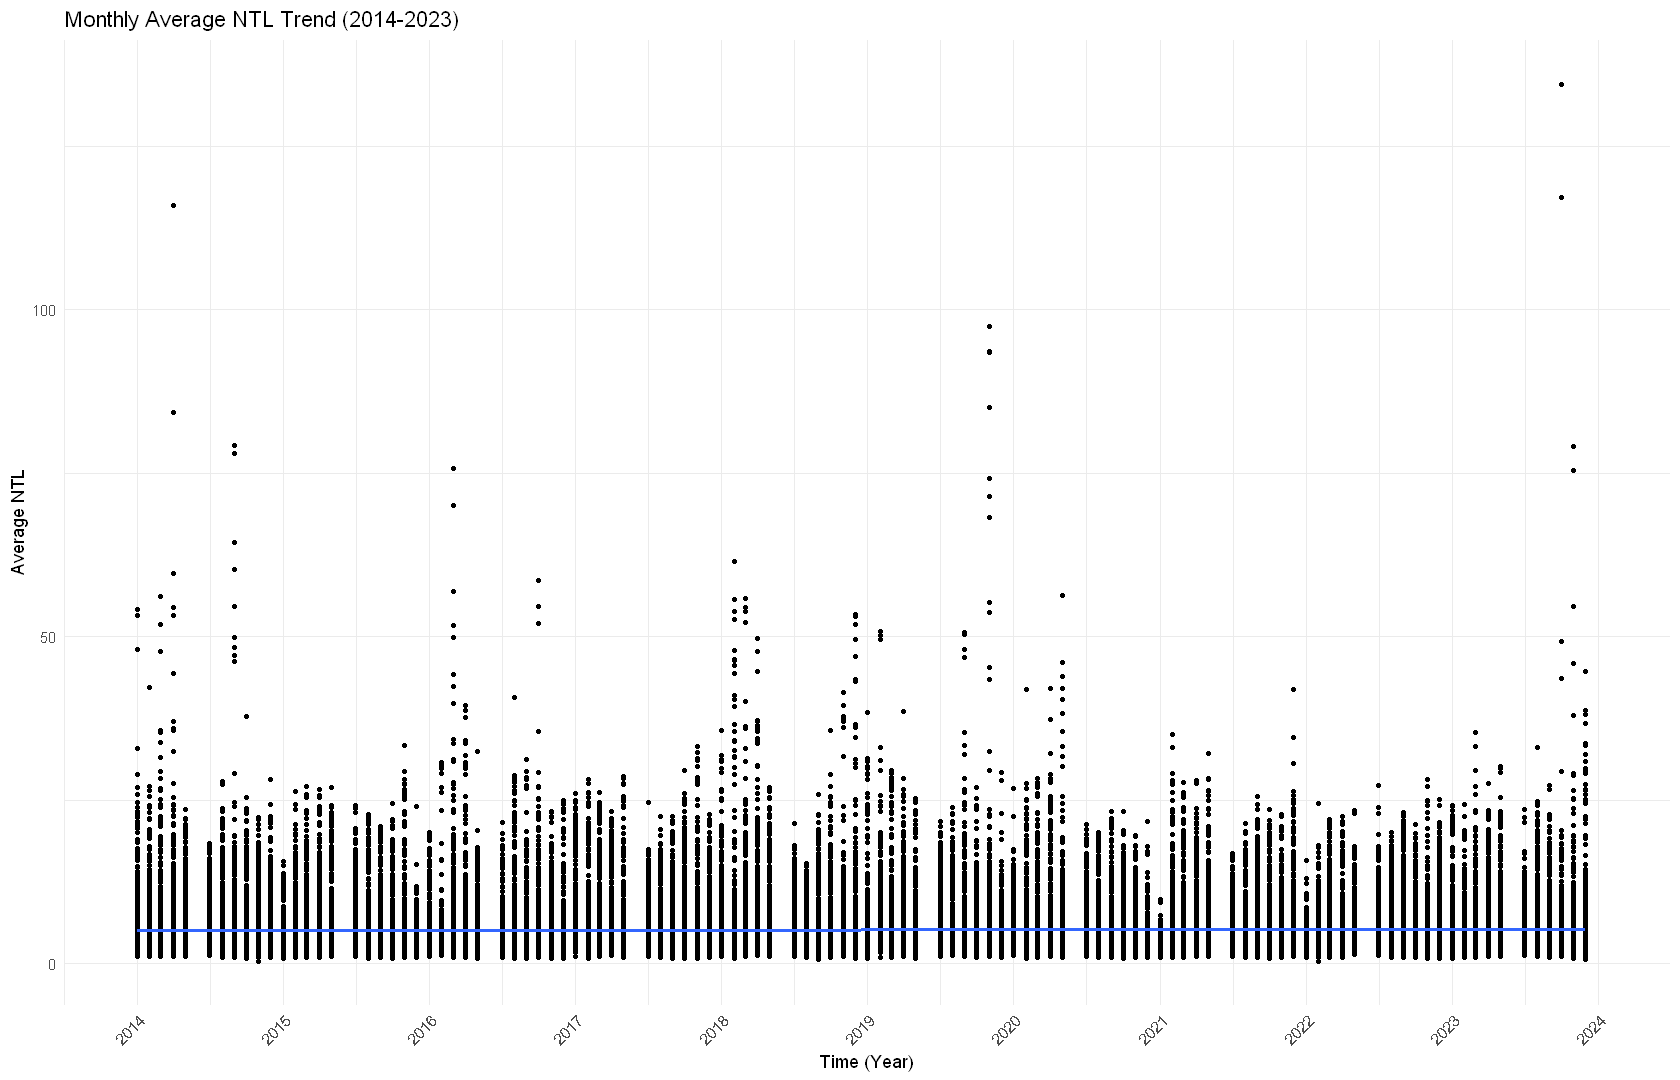

In [6]:
ggplot(census2016_2021_panel_night, aes(x = date, y = ntl_mean)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  geom_smooth(method = "lm") + 
  labs(x = "Time (Year)", y = "Average NTL", 
       title = "Monthly Average NTL Trend (2014-2023)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

#### Census Divisions Models

In [7]:
library(plm)

Warning message:
"package 'plm' was built under R version 4.4.3"

Attaching package: 'plm'


The following objects are masked from 'package:dplyr':

    between, lag, lead




In [8]:
model0 <- plm(expected_crime ~ ntl_mean * is_downtown + year + month, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(model0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + year + 
    month, data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-14.6077113  -0.1032458   0.0049142   0.0916115  15.9885402 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean             -0.01474048  0.00136713 -10.7821 < 2.2e-16 ***
year                 -0.05184995  0.00060082 -86.2982 < 2.2e-16 ***
month                 0.00896210  0.00047753  18.7677 < 2.2e-16 ***
ntl_mean:is_downtown  0.01199364  0.00178767   6.7091 1.968e-11 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    35736
Residual Sum of Squares: 33165
R-Squared:      0.07195
Adj. R-Squared: 0.063259
F-statistic: 2059.39 on 4 and 106253 DF, p-value: 

In [9]:
model1 <- plm(expected_crime ~ ntl_mean * is_downtown + year + month + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model1)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + year + 
    month + population_density + income, data = census2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-14.6359659  -0.1063182   0.0085845   0.0981756  15.9986982 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean             -1.5520e-02  1.3507e-03 -11.4905 < 2.2e-16 ***
year                 -6.1557e-02  9.1337e-04 -67.3952 < 2.2e-16 ***
month                 8.9306e-03  4.7117e-04  18.9541 < 2.2e-16 ***
population_density    8.6282e-05  1.6301e-06  52.9298 < 2.2e-16 ***
income                2.4489e-01  2.7728e-02   8.8320 < 2.2e-16 ***
ntl_mean:is_downtown  1.3469e-02  1.7651e-03   7.6305 2.357e-14 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '

In [10]:
model2 <- plm(expected_crime ~ ntl_mean + expected_day_crime  + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model2)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean + expected_day_crime + 
    population_density + income, data = census2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-18.861268  -0.079732  -0.011639   0.071801  23.537803 

Coefficients:
                      Estimate  Std. Error t-value  Pr(>|t|)    
ntl_mean           -7.7072e-03  7.4631e-04 -10.327 < 2.2e-16 ***
expected_day_crime  4.5476e-01  2.1724e-03 209.339 < 2.2e-16 ***
population_density  5.7129e-05  1.4047e-06  40.671 < 2.2e-16 ***
income             -8.1555e-01  1.5639e-02 -52.148 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    35736
Residual Sum of Squares: 23937
R-Squared:      0.33019
Adj. R-Squared: 0.32392
F-statistic: 13094.6 on 4 and 106253 DF, p-va

In [11]:
# We run bptest to check for heteroskedasticity
bptest(model0, studentize = TRUE)


	studentized Breusch-Pagan test

data:  model0
BP = 5991.6, df = 5, p-value < 2.2e-16


The result shows the models are likely heteroskedastic, so we include a clustered standard error to correct for the significance.

In [12]:
clustered_se0 <- sqrt(diag(vcovHC(model0, type = "HC0", cluster = "group")))
clustered_se1 <- sqrt(diag(vcovHC(model1, type = "HC0", cluster = "group")))
clustered_se2 <- sqrt(diag(vcovHC(model2, type = "HC0", cluster = "group")))

We want to have a better interpretability of how crime would change, so we are switching to a $log-log$ model.

In [13]:
model_log0 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + year + month, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    year + month, data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-0.956976 -0.112573 -0.011066  0.097464  1.076934 

Coefficients:
                             Estimate  Std. Error   t-value  Pr(>|t|)    
log(ntl_mean)             -0.05959119  0.00222639  -26.7658 < 2.2e-16 ***
year                      -0.04922840  0.00016378 -300.5775 < 2.2e-16 ***
month                      0.00663342  0.00013058   50.7979 < 2.2e-16 ***
log(ntl_mean):is_downtown  0.05142064  0.00641783    8.0122 1.138e-15 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    4702.1
Residual Sum of Squares: 2450.6
R-Squared:      0.47883
Adj. R-Squared: 0.47395
F-statistic: 24405.5 on 4 and

In [14]:
model_log1 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_log1)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime, data = census2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-1.864303 -0.194636  0.053062  0.155170  1.749624 

Coefficients:
                             Estimate  Std. Error t-value  Pr(>|t|)    
log(ntl_mean)             -0.16252083  0.00289374 -56.163 < 2.2e-16 ***
expected_day_crime         0.07306895  0.00091531  79.830 < 2.2e-16 ***
log(ntl_mean):is_downtown  0.17161203  0.00850305  20.182 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    4702.1
Residual Sum of Squares: 4321.1
R-Squared:      0.081023
Adj. R-Squared: 0.072426
F-statistic: 3122.67 on 3 and 106254 DF, p-value: < 2.22e-16

In [15]:
model_log2 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_log2)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime + population_density + income, data = census2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-1.3012219 -0.1200399  0.0015233  0.0998955  1.2017684 

Coefficients:
                             Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -9.2207e-02  2.4525e-03  -37.597 < 2.2e-16 ***
expected_day_crime         5.1753e-02  7.7436e-04   66.834 < 2.2e-16 ***
population_density         4.1028e-05  5.0051e-07   81.972 < 2.2e-16 ***
income                    -1.1394e+00  5.6196e-03 -202.754 < 2.2e-16 ***
log(ntl_mean):is_downtown  1.0461e-01  7.1414e-03   14.649 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squar

In [16]:
# We run bptest to check for heteroskedasticity
bptest(model_log0, studentize = TRUE)


	studentized Breusch-Pagan test

data:  model_log0
BP = 8600.4, df = 5, p-value < 2.2e-16


In [17]:
clustered_log_se0 <- sqrt(diag(vcovHC(model_log0, type = "HC0", cluster = "group")))
clustered_log_se1 <- sqrt(diag(vcovHC(model_log1, type = "HC0", cluster = "group")))
clustered_log_se2 <- sqrt(diag(vcovHC(model_log2, type = "HC0", cluster = "group")))

We run robustness check on the unadjusted crime counts

In [18]:
model_count0 <- plm(crime_count ~ ntl_mean * is_downtown + year + month + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_count0)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + year + month + 
    population_density + income, data = census2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-42.17685  -0.68375  -0.30666   0.48807  60.10702 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean             -1.2243e-03  4.2324e-03  -0.2893    0.7724    
year                 -4.4462e-02  2.8621e-03 -15.5350 < 2.2e-16 ***
month                 1.1030e-02  1.4764e-03   7.4711 8.013e-14 ***
population_density    7.1066e-06  5.1080e-06   1.3913    0.1642    
income               -8.7148e-03  8.6886e-02  -0.1003    0.9201    
ntl_mean:is_downtown  2.4452e-02  5.5311e-03   4.4207 9.847e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum

In [19]:
model_count1 <- plm(crime_count ~ ntl_mean * is_downtown + day_crime_count + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_count1)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + day_crime_count + 
    population_density + income, data = census2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 55-110, N = 107249

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-41.47568  -0.65656  -0.29498   0.53068  60.02379 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean             -1.7243e-02  3.9278e-03  -4.3901 1.134e-05 ***
day_crime_count       4.0581e-01  3.2663e-03 124.2419 < 2.2e-16 ***
population_density    6.2303e-06  4.7703e-06   1.3061    0.1915    
income               -7.5068e-01  5.3153e-02 -14.1232 < 2.2e-16 ***
ntl_mean:is_downtown  4.7599e-02  5.1551e-03   9.2334 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    319050
Residual Sum of Squares: 277570
R-Squared:

In [20]:
clustered_count_se0 <- sqrt(diag(vcovHC(model_count0, type = "HC0", cluster = "group")))
clustered_count_se1 <- sqrt(diag(vcovHC(model_count1, type = "HC0", cluster = "group")))

##### Summary Tables

In [21]:
census_summary1 <- stargazer(list(model0, model1, model2),
          type = "text",                   
          title = "Regression of Expected Crime on Average NTL in the Scale of Census Divisions",
          dep.var.labels = "Expected Crime",
          covariate.labels = c("Average NTL",
                               "Expected Day Crime",
                               "Population Density",
                               "Income (in $100,000)",
                               "Average NTL x is Downtown"),
          # add.lines = list(
          #   c("Fixed Effects", "Month & Year")  
          # ),
          se = list(clustered_se0, clustered_se1, clustered_se2),
          omit = c("^(year)", "^(month)"),      # omit coefficients starting with "year" or "month"
          omit.labels = c("Year", "Month"),
          single.row = FALSE,
          omit.stat = c("f", "ser"),
          notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses.",
          notes.align = "l",
          star.cutoffs = c(0.1, 0.05, 0.01))   


Regression of Expected Crime on Average NTL in the Scale of Census Divisions
                                                                                               Dependent variable:                                                                     
                          -------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                                                 Expected Crime                                                                        
                                                  (1)                                                  (2)                                                  (3)                        
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Av

In [22]:
census_summary2 <- stargazer(list(model_log0, model_log1, model_log2),
          type = "text",                   
          title = "log -log Regression of Expected Crime on Average NTL in the Scale of Census Divisions",
          dep.var.labels = "log(Expected Crime)",
          covariate.labels = c("log (Average NTL)",
                               "Expected Day Crime",
                               "Population Density",
                               "Income (in $100,000)",
                               "log(Average NTL) x is Downtown"),
          # add.lines = list(
          #   c("Fixed Effects", "Month & Year")  
          # ),
          se = list(clustered_log_se0, clustered_log_se1, clustered_log_se2),
          omit = c("^(year)", "^(month)"),      # omit coefficients starting with "year" or "month"
          omit.labels = c("Year", "Month"),
          single.row = FALSE,
          omit.stat = c("f", "ser"),
          notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses.",
          notes.align = "l",
          star.cutoffs = c(0.1, 0.05, 0.01))   


log -log Regression of Expected Crime on Average NTL in the Scale of Census Divisions
                                                                                                    Dependent variable:                                                                     
                               -------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                                                    log(Expected Crime)                                                                     
                                                       (1)                                                  (2)                                                  (3)                        
-------------------------------------------------------------------------------------------------------------------------------------------------------------

In [23]:
census_summary3 <- stargazer(list(model_count0, model_count1),
          type = "text",                   
          title = "Regression of Crime Counts on Average NTL in the Scale of Census Divisions",
          dep.var.labels = c("Crime Count"),
          covariate.labels = c("Average NTL",
                               "Daytime Crime Count",
                               "Population Density",
                               "Income (in $100,000)",
                               "Average NTL x is Downtown"),
          # add.lines = list(
          #   c("Fixed Effects", "Month & Year")  
          # ),
          se = list(clustered_count_se0, clustered_count_se1),
          omit = c("^(year)", "^(month)"),      # omit coefficients starting with "year" or "month"
          omit.labels = c("Year", "Month"),
          single.row = FALSE,
          omit.stat = c("f", "ser"),
          notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses.",
          notes.align = "l",
          star.cutoffs = c(0.1, 0.05, 0.01))   


Regression of Crime Counts on Average NTL in the Scale of Census Divisions
                                                                                              Dependent variable:                                                                     
                          ------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                                                  Crime Count                                                                         
                                                               (1)                                                                            (2)                                     
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Average N

#### Explorations on 22 Neighborhoods

In [24]:
neighborhood2016_2021_panel <- read_csv("neighborhood2016_2021_panel.csv")

Rows: 5280 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): neighborhood, time_category
dbl  (12): year, month, population, area_sq_km, population_density, income, ...
lgl   (1): electric_index
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [25]:
neighborhood2016_2021_panel_night <- neighborhood2016_2021_panel|>
    filter(time_category == "night")|>
    mutate(neighborhood = as.factor(neighborhood))|>
    mutate(month = factor(month, levels = c("6", setdiff(sort(unique(as.character(month))), "6"))))|>
    mutate(year = as.factor(year))|>
    mutate(income = as.numeric(income))|>
    filter(!is.na(income))|>
    glimpse()

Rows: 2,640
Columns: 16
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, …
$ time_category      <chr> "night", "night", "night", "night", "night", "night…
$ population         <dbl> 14726, 14726, 14726, 14726, 14726, 14726, 14726, 14…
$ area_sq_km         <dbl> 3.56967, 3.56967, 3.56967, 3.56967, 3.56967, 3.5696…
$ population_density <dbl> 4125.311, 4125.311, 4125.311, 4125.311, 4125.311, 4…
$ income             <dbl> 0.8086515, 0.8086515, 0.8086515, 0.8086515, 0.80865…
$ crime_count        <dbl> 17, 19, 11, 22, 24, 31, 17, 13, 28, 24, 29, 20, 23,…
$ electric_index     <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ date               <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.063007, 3.580293, 2.952030, 3.427922, N…
$ n_pixels      

In [26]:
# Check if there are 0 value
sum(neighborhood2016_2021_panel_night$crime_count == 0)

[1] 0

In [27]:
# Adding day crime as a control
neighborhood2016_2021_panel_day <- neighborhood2016_2021_panel|>
    filter(time_category == "day")|>
    mutate(day_crime_count = crime_count)|>
    dplyr::select(neighborhood, date, day_crime_count)

neighborhood2016_2021_panel_night <- neighborhood2016_2021_panel_night|>
    left_join(neighborhood2016_2021_panel_day, by = c("date", "neighborhood"))|>
    mutate(day_crime_count = ifelse(is.na(day_crime_count), 0, day_crime_count))|>
    mutate(neighborhood = as.factor(neighborhood))|>
    glimpse()

Rows: 2,640
Columns: 17
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, …
$ time_category      <chr> "night", "night", "night", "night", "night", "night…
$ population         <dbl> 14726, 14726, 14726, 14726, 14726, 14726, 14726, 14…
$ area_sq_km         <dbl> 3.56967, 3.56967, 3.56967, 3.56967, 3.56967, 3.5696…
$ population_density <dbl> 4125.311, 4125.311, 4125.311, 4125.311, 4125.311, 4…
$ income             <dbl> 0.8086515, 0.8086515, 0.8086515, 0.8086515, 0.80865…
$ crime_count        <dbl> 17, 19, 11, 22, 24, 31, 17, 13, 28, 24, 29, 20, 23,…
$ electric_index     <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ date               <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.063007, 3.580293, 2.952030, 3.427922, N…
$ n_pixels      

In [28]:
# A balancing table of neighborhood panel
covariates <- c("is_downtown", "electric_index", "income", "expected_day_crime",
                "population_density")

# Here we assign "High" if above the median and "Low" otherwise.
neighborhood2016_2021_panel_night$treated <- ifelse(
 neighborhood2016_2021_panel_night$ntl_mean > median(neighborhood2016_2021_panel_night$ntl_mean, na.rm = TRUE), 
  "High", 
  "Low"
)

# Generate the balancing table using the CreateTableOne function.
bal_table <- CreateTableOne(vars = covariates, strata = "treated", 
                            data = neighborhood2016_2021_panel_night, test = TRUE)

# Print the table with standardized mean differences (SMD)
print(bal_table, smd = TRUE)

Warning message in ModuleReturnVarsExist(vars, data):
"The data frame does not have: expected_day_crime  Dropped"
Warning message in ModuleReturnVarsExist(vars, data):
"These variables only have NA/NaN: electric_index  Dropped"


                                Stratified by treated
                                 High              Low               p     
  n                                 1210              1210                 
  is_downtown (mean (SD))           0.09 (0.29)       0.00 (0.00)    <0.001
  income (mean (SD))                0.74 (0.17)       0.95 (0.19)    <0.001
  population_density (mean (SD)) 8619.08 (5967.44) 4300.90 (1926.55) <0.001
                                Stratified by treated
                                 test SMD   
  n                                         
  is_downtown (mean (SD))              0.447
  income (mean (SD))                   1.136
  population_density (mean (SD))       0.974


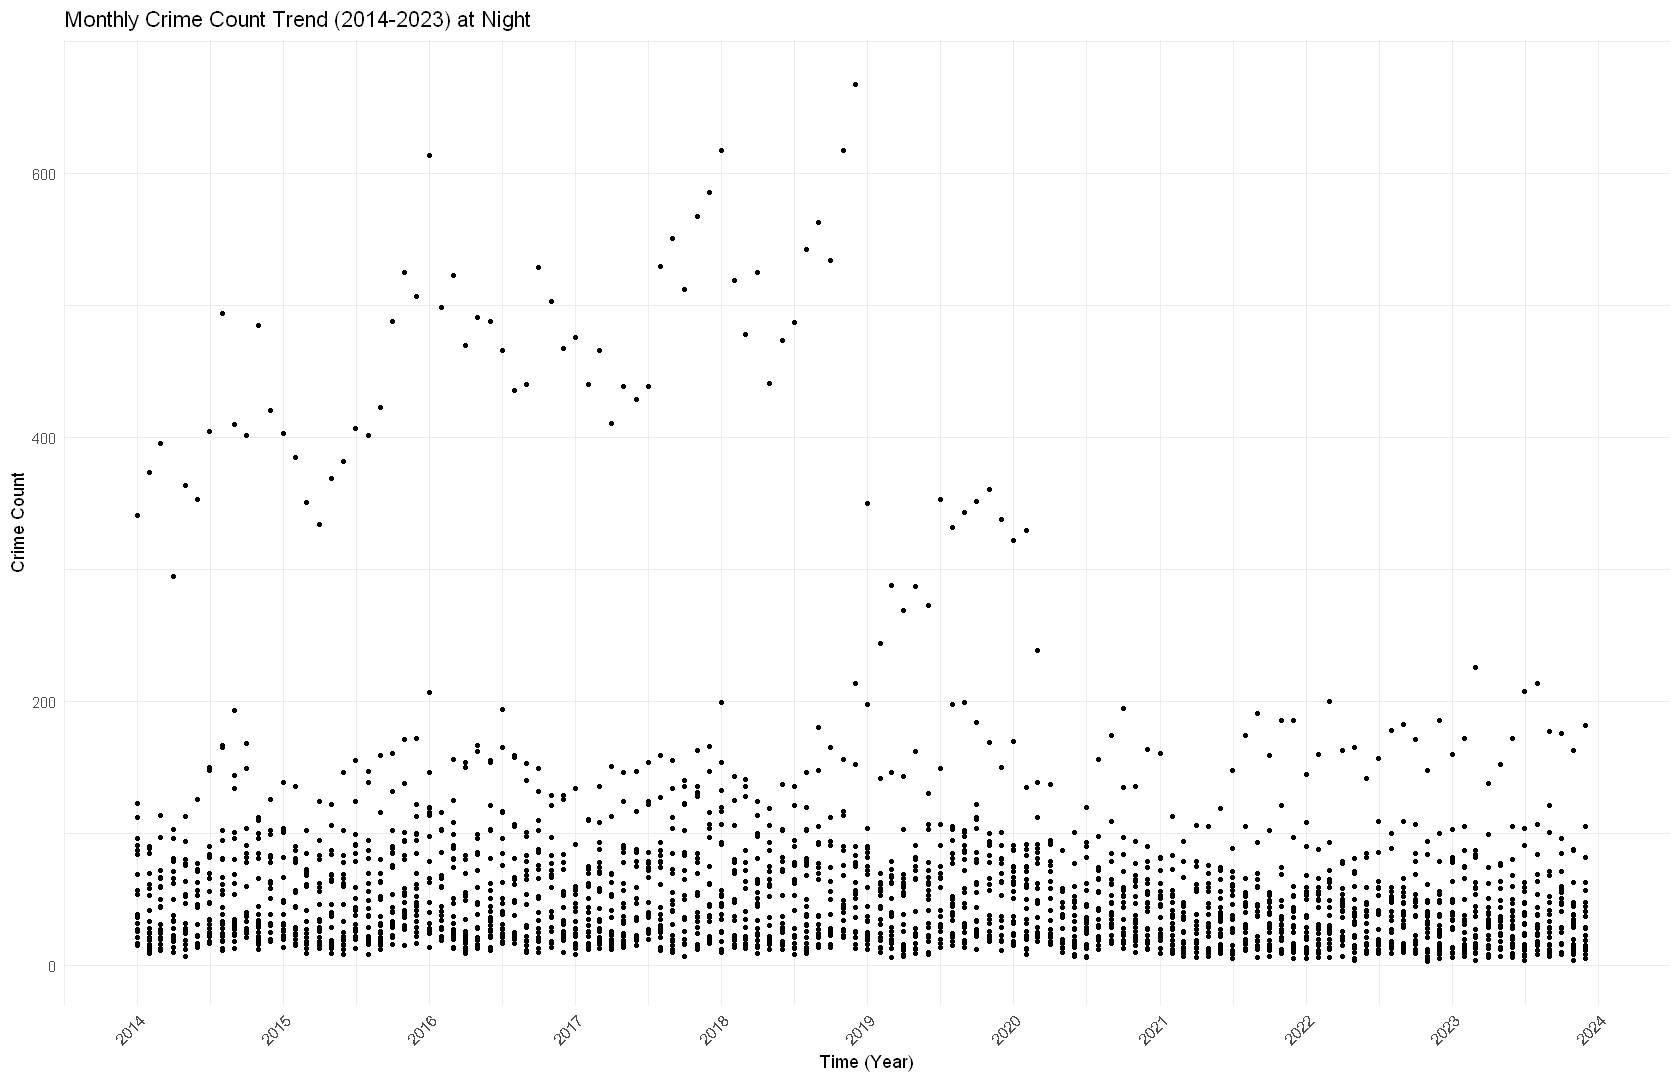

In [29]:
# Plot for crime count
options(repr.plot.width = 14, repr.plot.height = 9)

# Plot for actual crime count
neighborhood_night_count_dist <- ggplot(neighborhood2016_2021_panel_night, aes(x = date, y = crime_count)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2014-2023) at Night") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Combine the two plots side by side
neighborhood_night_count_dist

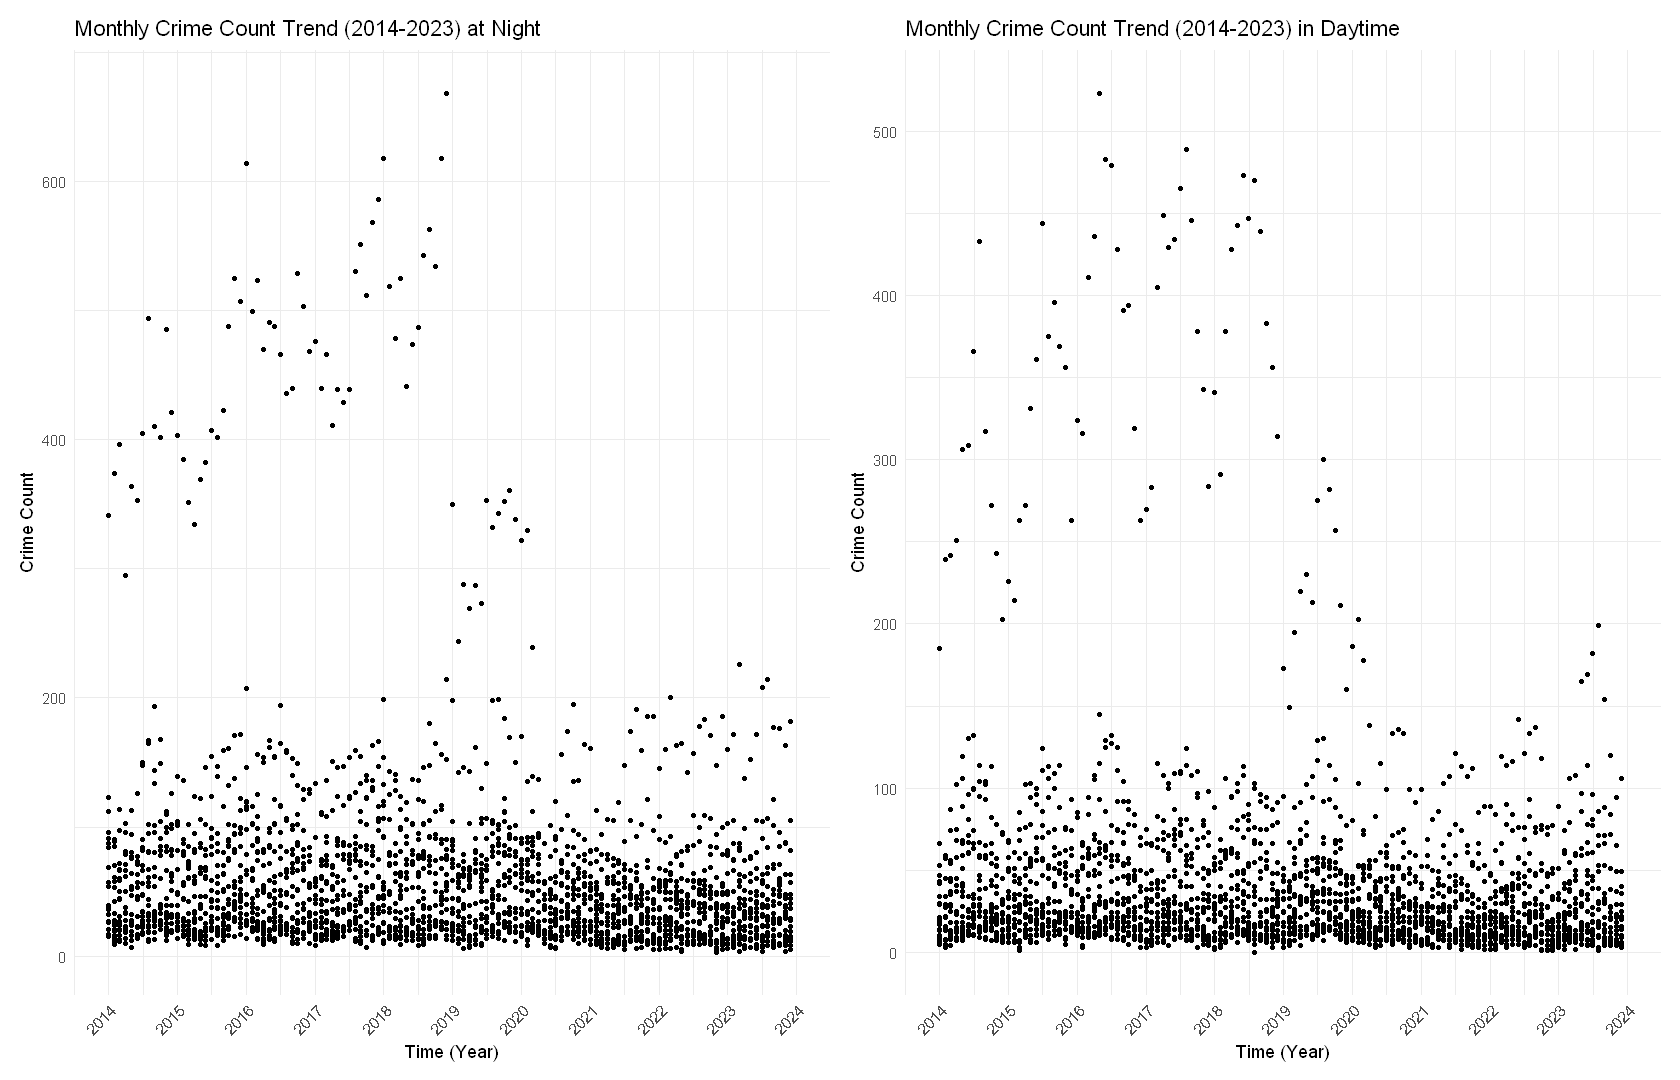

In [30]:
# Plot for expected crime count
options(repr.plot.width = 14, repr.plot.height = 9)

# Plot for actual crime count
neighborhood_day_count_dist <- ggplot(neighborhood2016_2021_panel_night, aes(x = date, y = day_crime_count)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
               limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2014-2023) in Daytime") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Combine the two plots side by side
neighborhood_night_count_dist + neighborhood_day_count_dist

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 220 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 220 rows containing missing values or values outside the scale range
(`geom_point()`)."


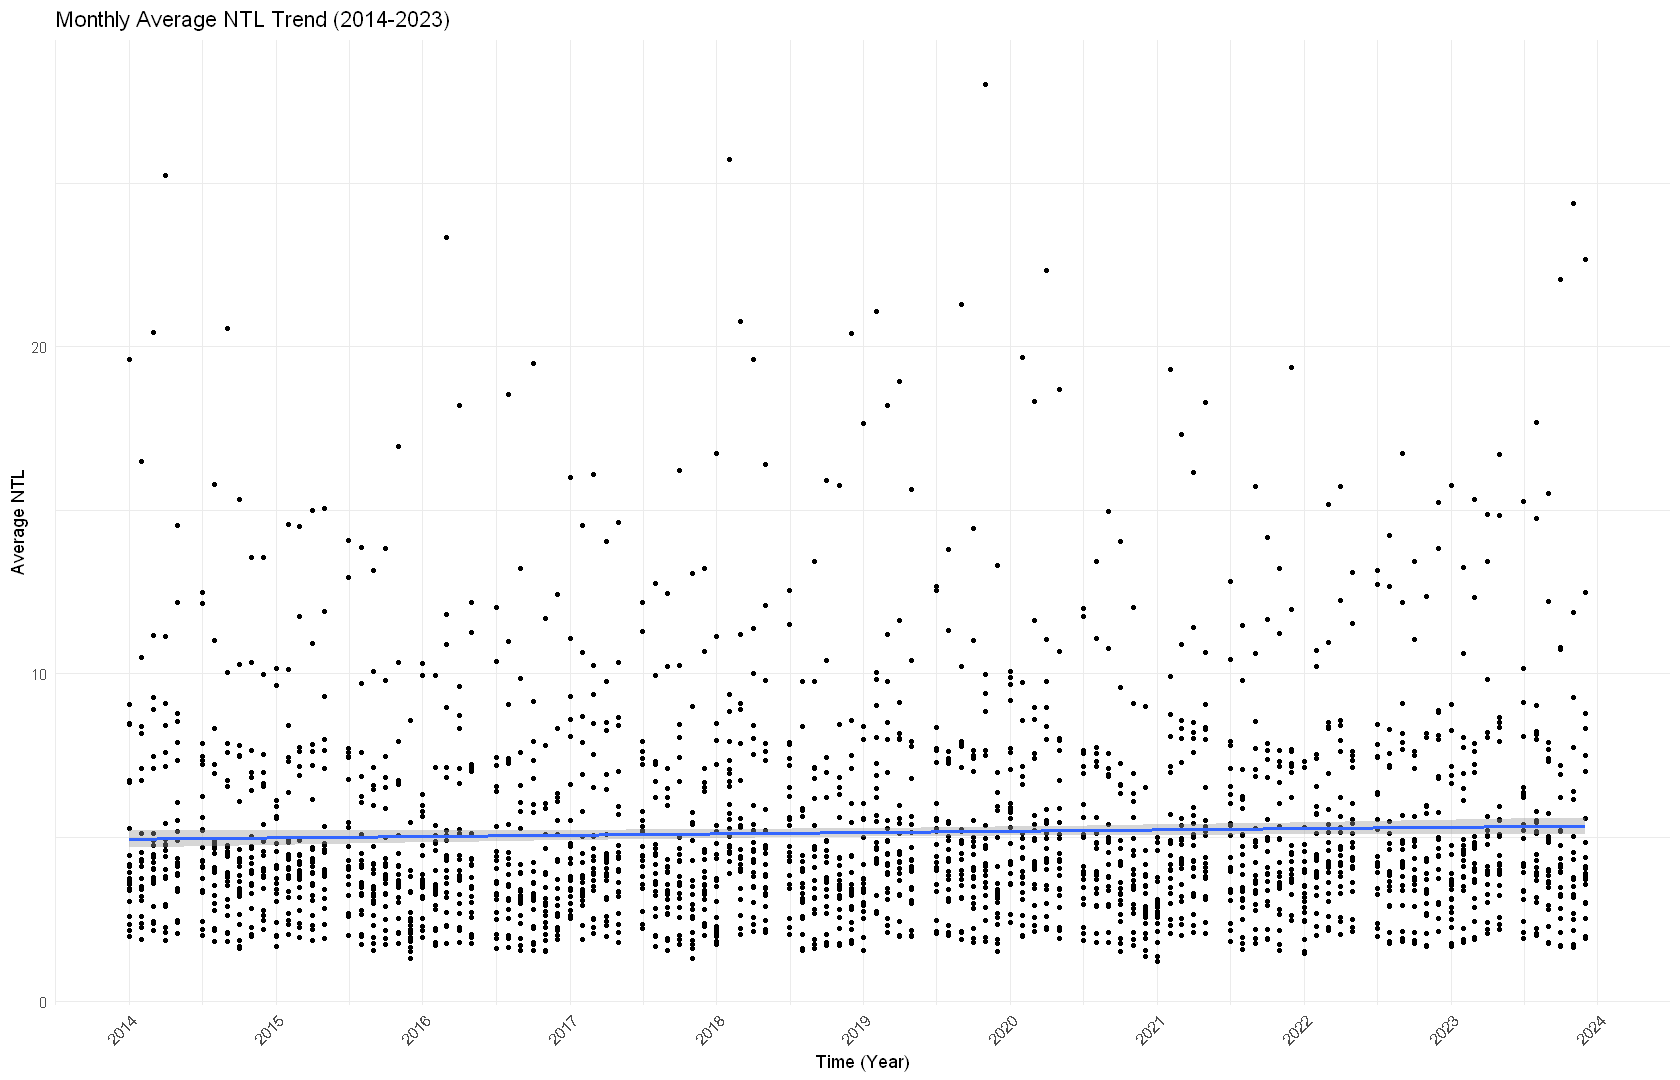

In [31]:
ggplot(neighborhood2016_2021_panel_night, aes(x = date, y = ntl_mean)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2023-12-31"))) +
  geom_smooth(method = "lm") + 
  labs(x = "Time (Year)", y = "Average NTL", 
       title = "Monthly Average NTL Trend (2014-2023)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

#### Neighborhood Models

We check the robustness by running models on crime counts.

In [32]:
neighborhood_model0 <- plm(crime_count ~ ntl_mean * is_downtown + year + month + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model0)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + year + month + 
    population_density + income, data = neighborhood2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-207.26062  -11.61812   -0.68692   10.79329  287.94110 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean               0.3626971   0.9123966   0.3975 0.6910188    
year2015               2.2127812   2.8910051   0.7654 0.4441082    
year2016               9.6895529   2.9050884   3.3354 0.0008650 ***
year2017               6.4355544   2.8768112   2.2370 0.0253759 *  
year2018              10.4984537   2.8685290   3.6599 0.0002578 ***
year2019               3.2198774   7.5144017   0.4285 0.6683302    
year2020             -11.7636524   7.5272662  -1.5628 0.11823

In [33]:
neighborhood_model1 <- plm(crime_count ~ ntl_mean * is_downtown + day_crime_count, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model1)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + day_crime_count, 
    data = neighborhood2016_2021_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-129.78225   -7.96461   -0.96567    6.39740  259.00150 

Coefficients:
                      Estimate Std. Error t-value  Pr(>|t|)    
ntl_mean             -4.150012   0.537702 -7.7181 1.721e-14 ***
day_crime_count       1.014073   0.014134 71.7478 < 2.2e-16 ***
ntl_mean:is_downtown  4.956242   0.737389  6.7213 2.243e-11 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    3385000
Residual Sum of Squares: 1068300
R-Squared:      0.68439
Adj. R-Squared: 0.68123
F-statistic: 1731.19 on 3 and 2395 DF, p-value: < 2.22e-16

In [34]:
neighborhood_model2 <- plm(crime_count ~ ntl_mean * is_downtown + day_crime_count + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model2)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + day_crime_count + 
    population_density + income, data = neighborhood2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-123.99644   -8.10359   -0.87703    6.78161  255.07795 

Coefficients:
                       Estimate Std. Error t-value  Pr(>|t|)    
ntl_mean             -3.4629988  0.5386616 -6.4289 1.546e-10 ***
day_crime_count       0.9423783  0.0158954 59.2861 < 2.2e-16 ***
population_density   -0.0177307  0.0024534 -7.2269 6.616e-13 ***
income               -8.5624659  6.4079328 -1.3362    0.1816    
ntl_mean:is_downtown  4.2740357  0.7322125  5.8372 6.030e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    3385000
Residual Sum of Squares: 1030500
R-Squared:

In [35]:
neighborhood_model_log1 <- plm(log(crime_count) ~ log(ntl_mean) * is_downtown + day_crime_count, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log1)

Oneway (individual) effect Within Model

Call:
plm(formula = log(crime_count) ~ log(ntl_mean) * is_downtown + 
    day_crime_count, data = neighborhood2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-1.673183 -0.192319  0.023796  0.217617  0.994636 

Coefficients:
                             Estimate  Std. Error t-value  Pr(>|t|)    
log(ntl_mean)             -0.33509731  0.04125214 -8.1231 7.194e-16 ***
day_crime_count            0.00534314  0.00021966 24.3245 < 2.2e-16 ***
log(ntl_mean):is_downtown  0.38110702  0.12348904  3.0862  0.002051 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    328.55
Residual Sum of Squares: 258.29
R-Squared:      0.21385
Adj. R-Squared: 0.20597
F-statistic: 217.166 on 3 and 2395 DF, p-value: < 2.22e-16

In [36]:
neighborhood_model_log2 <- plm(log(crime_count) ~ log(ntl_mean) * is_downtown + day_crime_count + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log2)

Oneway (individual) effect Within Model

Call:
plm(formula = log(crime_count) ~ log(ntl_mean) * is_downtown + 
    day_crime_count + population_density + income, data = neighborhood2016_2021_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 110, N = 2420

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-1.581442 -0.187909  0.014773  0.203646  1.040810 

Coefficients:
                             Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -2.1090e-01  4.0157e-02  -5.2520 1.638e-07 ***
day_crime_count            4.1755e-03  2.3985e-04  17.4087 < 2.2e-16 ***
population_density        -9.0735e-05  3.7028e-05  -2.4504   0.01434 *  
income                    -1.1416e+00  9.6813e-02 -11.7914 < 2.2e-16 ***
log(ntl_mean):is_downtown  2.6123e-01  1.1803e-01   2.2132   0.02698 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    328

In [37]:
n_clustered_se0 <- sqrt(diag(vcovHC(neighborhood_model0, type = "HC0", cluster = "group")))
n_clustered_se1 <- sqrt(diag(vcovHC(neighborhood_model1, type = "HC0", cluster = "group")))
n_clustered_se2 <- sqrt(diag(vcovHC(neighborhood_model2, type = "HC0", cluster = "group")))
n_clustered_log_se1 <- sqrt(diag(vcovHC(neighborhood_model_log1, type = "HC0", cluster = "group")))
n_clustered_log_se2 <- sqrt(diag(vcovHC(neighborhood_model_log2, type = "HC0", cluster = "group")))

##### Summary Tables

In [38]:
neighborhood_summary1 <- stargazer(list(neighborhood_model0,  neighborhood_model1, neighborhood_model2), 
    type = "text",                   
    title = "Regression of Crime Count on Average NTL in the Scale of Neighborhoods",
    dep.var.labels = "Crime Count",
    covariate.labels = c("Average NTL",
                        "Population Density",
                        "Income (in $100,000)",
                        "Daytime Crime Count", 
                        "Average NTL x is Downtown"),
    se = list(n_clustered_se0, n_clustered_se1, n_clustered_se2),
    omit = c("^(year)", "^(month)"),
    omit.labels = c("Year", "Month"),
    single.row = FALSE,
    omit.stat = c("f", "ser"),
    notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses.",
    notes.align = "l",
    star.cutoffs = c(0.1, 0.05, 0.01))


Regression of Crime Count on Average NTL in the Scale of Neighborhoods
                                                                                               Dependent variable:                                                                     
                          -------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                                                   Crime Count                                                                         
                                                  (1)                                                  (2)                                                  (3)                        
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Average 

In [39]:

neighborhood_summary2 <- stargazer(list(neighborhood_model_log1, neighborhood_model_log2),
          type = "text",                   
          title = "log-log Regression of Crime Count on Average NTL in the Scale of Neighborhoods",
          dep.var.labels = "log (Crime Count)",
          covariate.labels = c("log (Average NTL)",
                               "Expected Day Crime",
                               "Population Density",
                               "Income (in $100,000)",
                               "log(Average NTL) x is Downtown"),
          se = list(n_clustered_log_se1, n_clustered_log_se2),
          omit = c("^(year)", "^(month)"),      # omit coefficients starting with "year" or "month"
          omit.labels = c("Year", "Month"),
          single.row = FALSE,
          omit.stat = c("f", "ser"),
          notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses.",
          notes.align = "l",
          star.cutoffs = c(0.1, 0.05, 0.01))  



log-log Regression of Crime Count on Average NTL in the Scale of Neighborhoods
                                                                                                   Dependent variable:                                                                     
                               ------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                                                    log (Crime Count)                                                                      
                                                                    (1)                                                                            (2)                                     
------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### Heterougeneous Analysis on Two Scales

In [40]:
# Studying from the scale of census divisions
census2016_2021_panel_dt <- census2016_2021_panel_night|>
    filter(neighborhood == "Downtown")

census2016_2021_panel_ut <- census2016_2021_panel_night|>
    filter(neighborhood != "Downtown")

In [41]:
model_dt0 <- plm(expected_crime ~ ntl_mean + expected_day_crime + population_density + income, 
                            index = c("name", "date"),
                            data = census2016_2021_panel_dt, 
                            model = "within", 
                            effect = "individual")

summary(model_dt0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean + expected_day_crime + 
    population_density + income, data = census2016_2021_panel_dt, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 53, T = 55-110, N = 5444

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-18.40362  -0.30078  -0.02153   0.28554  22.81658 

Coefficients:
                      Estimate  Std. Error t-value  Pr(>|t|)    
ntl_mean            3.9241e-03  3.5358e-03  1.1098    0.2671    
expected_day_crime  4.2138e-01  9.7926e-03 43.0301 < 2.2e-16 ***
population_density  6.2022e-05  7.6979e-06  8.0570 9.547e-16 ***
income             -3.0974e+00  3.1392e-01 -9.8668 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    22036
Residual Sum of Squares: 15781
R-Squared:      0.28386
Adj. R-Squared: 0.27642
F-statistic: 533.83 on 4 and 5387 DF, p-value: < 2.22e-16

In [42]:
model_ut0 <- plm(expected_crime ~ ntl_mean + expected_day_crime + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_ut, 
                             model = "within", 
                             effect = "individual")

summary(model_ut0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean + expected_day_crime + 
    population_density + income, data = census2016_2021_panel_ut, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 937, T = 55-110, N = 101585

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-9.766180 -0.073919 -0.010613  0.065165 12.325862 

Coefficients:
                      Estimate  Std. Error t-value  Pr(>|t|)    
ntl_mean           -2.6605e-02  6.7342e-04 -39.507 < 2.2e-16 ***
expected_day_crime  5.1398e-01  2.1901e-03 234.681 < 2.2e-16 ***
population_density  6.4795e-05  1.1279e-06  57.449 < 2.2e-16 ***
income             -6.7735e-01  9.4131e-03 -71.958 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    13503
Residual Sum of Squares: 7720.3
R-Squared:      0.42823
Adj. R-Squared: 0.42289
F-statistic: 18844.8 on 4 and 100644 DF, p-value: < 2.22e

In [43]:
model_dt_log0 <- plm(log(expected_crime) ~ log(ntl_mean) + expected_day_crime + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_dt, 
                             model = "within", 
                             effect = "individual")

summary(model_dt_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) + expected_day_crime + 
    population_density + income, data = census2016_2021_panel_dt, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 53, T = 55-110, N = 5444

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.6414617 -0.1216470  0.0066703  0.1067278  0.6145390 

Coefficients:
                      Estimate  Std. Error  t-value Pr(>|t|)    
log(ntl_mean)       4.5689e-03  6.9221e-03   0.6601   0.5092    
expected_day_crime  2.5139e-02  9.9760e-04  25.1991   <2e-16 ***
population_density  1.5022e-05  7.8506e-07  19.1347   <2e-16 ***
income             -1.0373e+00  3.2002e-02 -32.4154   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    226.09
Residual Sum of Squares: 164.07
R-Squared:      0.2743
Adj. R-Squared: 0.26676
F-statistic: 509.053 on 4 and 5387 DF, p

In [44]:
model_ut_log0 <- plm(log(expected_crime) ~ log(ntl_mean) + expected_day_crime + population_density + income, 
                            index = c("name", "date"),
                             data = census2016_2021_panel_ut, 
                             model = "within", 
                             effect = "individual")

summary(model_ut_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) + expected_day_crime + 
    population_density + income, data = census2016_2021_panel_ut, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 937, T = 55-110, N = 101585

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-1.24647489 -0.11701540  0.00061619  0.09684545  1.15316260 

Coefficients:
                      Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)      -9.7644e-02  2.3962e-03  -40.750 < 2.2e-16 ***
expected_day_crime  1.0214e-01  1.3049e-03   78.277 < 2.2e-16 ***
population_density  6.1242e-05  6.7130e-07   91.229 < 2.2e-16 ***
income             -1.1169e+00  5.6331e-03 -198.269 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    4466
Residual Sum of Squares: 2735.1
R-Squared:      0.38757
Adj. R-Squared: 0.38185
F-statistic: 15922.6 on

In [45]:
clustered_dt_se0 <- sqrt(diag(vcovHC(model_dt0, type = "HC0", cluster = "group")))
clustered_ut_se0 <- sqrt(diag(vcovHC(model_ut0, type = "HC0", cluster = "group")))
clustered_dt_log_se0 <- sqrt(diag(vcovHC(model_dt_log0, type = "HC0", cluster = "group")))
clustered_ut_log_se0 <- sqrt(diag(vcovHC(model_ut_log0, type = "HC0", cluster = "group")))

In [46]:
census_hetero_summary <- stargazer(list(model_dt0, model_ut0, model_dt_log0, model_ut_log0), 
    type = "text",                   
    column.labels = c("Downtown", "Urban Territory", "Downtown", "Urban Territory"),
    dep.var.labels = c("Expected Crime", "log(Expected Crime)"),
    model.numbers = FALSE,
    title = "Downtown-Urban Hetergonous Regression of Expected Crime on Average NTL in the Scale of Census Divisions",
    covariate.labels = c("Average NTL",
                         "log(Average NTL)",
                        "Expected Day Crime Count",
                        "Population Density",
                        "Income (in $100,000)"),
    se = list(clustered_dt_se0, clustered_ut_se0, clustered_dt_log_se0, clustered_ut_log_se0),
    single.row = FALSE,
    omit.stat = c("f", "ser"),
    notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses.",
    notes.align = "l",
    star.cutoffs = c(0.1, 0.05, 0.01))


Downtown-Urban Hetergonous Regression of Expected Crime on Average NTL in the Scale of Census Divisions
                                                                                              Dependent variable:                                                                      
                         --------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                         Expected Crime                                                               log(Expected Crime)                              
                                        Downtown                             Urban Territory                            Downtown                            Urban Territory            
---------------------------------------------------------------------------------------------------------------------------------------------------------------

In [47]:
# Studying from the scale of neighborhoods
neighborhood2016_2021_panel_dt <- neighborhood2016_2021_panel_night|>
    filter(neighborhood == "Downtown")

neighborhood2016_2021_panel_ut <- neighborhood2016_2021_panel_night|>
    filter(neighborhood != "Downtown")

In [48]:
neighborhood_model_dt0 <- plm(crime_count ~ ntl_mean + day_crime_count + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_dt, 
                             model = "within", 
                             effect = "individual")

summary(neighborhood_model_dt0)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean + day_crime_count + population_density + 
    income, data = neighborhood2016_2021_panel_dt, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 1, T = 110, N = 110

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-128.744  -44.034  -11.505   35.704  214.298 

Coefficients: (1 dropped because of singularities)
                    Estimate Std. Error t-value  Pr(>|t|)    
ntl_mean            1.023675   1.595801  0.6415    0.5226    
day_crime_count     0.554245   0.089126  6.2187 1.012e-08 ***
population_density -0.161651   0.024670 -6.5525 2.095e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    2640800
Residual Sum of Squares: 473090
R-Squared:      0.82085
Adj. R-Squared: 0.81578
F-statistic: 161.896 on 3 and 106 DF, p-value: < 2.22e-16

In [49]:
neighborhood_model_ut0 <- plm(crime_count ~ ntl_mean + day_crime_count + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_ut, 
                             model = "within", 
                             effect = "individual")

summary(neighborhood_model_ut0)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean + day_crime_count + population_density + 
    income, data = neighborhood2016_2021_panel_ut, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 21, T = 110, N = 2310

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-51.32126  -7.21322  -0.92327   6.03290  92.29688 

Coefficients:
                      Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean            -3.4908222   0.3374819 -10.3437 < 2.2e-16 ***
day_crime_count      0.8116670   0.0225980  35.9177 < 2.2e-16 ***
population_density  -0.0067171   0.0015975  -4.2049 2.713e-05 ***
income             -19.5958050   4.0508279  -4.8375 1.403e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    744210
Residual Sum of Squares: 383410
R-Squared:      0.48481
Adj. R-Squared: 0.4794
F-statistic: 537.56 on 4 and 2285 DF, p-value: < 2.22e-16

In [50]:
neighborhood_model_dt_log0 <- plm(log(crime_count) ~ log(ntl_mean) + day_crime_count + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_dt, 
                             model = "within", 
                             effect = "individual")

summary(neighborhood_model_dt_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(crime_count) ~ log(ntl_mean) + day_crime_count + 
    population_density + income, data = neighborhood2016_2021_panel_dt, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 1, T = 110, N = 110

Residuals:
    Min.  1st Qu.   Median  3rd Qu.     Max. 
-0.66776 -0.14281 -0.01428  0.15984  0.54668 

Coefficients: (1 dropped because of singularities)
                      Estimate  Std. Error t-value  Pr(>|t|)    
log(ntl_mean)       5.1690e-02  8.4785e-02  0.6097    0.5434    
day_crime_count     2.0811e-03  3.1910e-04  6.5217 2.427e-09 ***
population_density -4.8906e-04  8.8324e-05 -5.5371 2.250e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    30.892
Residual Sum of Squares: 6.0632
R-Squared:      0.80373
Adj. R-Squared: 0.79817
F-statistic: 144.687 on 3 and 106 DF, p-value: < 2.22e-16

In [51]:
neighborhood_model_ut_log0 <- plm(log(crime_count) ~ log(ntl_mean) + day_crime_count + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_2021_panel_ut, 
                             model = "within", 
                             effect = "individual")

summary(neighborhood_model_ut_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(crime_count) ~ log(ntl_mean) + day_crime_count + 
    population_density + income, data = neighborhood2016_2021_panel_ut, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 21, T = 110, N = 2310

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-1.5509766 -0.1795601  0.0086658  0.1931578  1.0269239 

Coefficients:
                      Estimate  Std. Error t-value  Pr(>|t|)    
log(ntl_mean)      -2.6576e-01  3.8728e-02 -6.8623 8.696e-12 ***
day_crime_count     1.1509e-02  5.2511e-04 21.9167 < 2.2e-16 ***
population_density  5.5379e-07  3.7090e-05  0.0149    0.9881    
income             -9.2931e-01  9.4175e-02 -9.8679 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    297.66
Residual Sum of Squares: 206.71
R-Squared:      0.30555
Adj. R-Squared: 0.29826
F-statistic: 251.349 on 4 and 2285 D

In [52]:
n_clustered_dt_se0 <- sqrt(diag(vcovHC(neighborhood_model_dt0, type = "HC0", cluster = "group")))
n_clustered_ut_se0 <- sqrt(diag(vcovHC(neighborhood_model_ut0, type = "HC0", cluster = "group")))
n_clustered_dt_log_se0 <- sqrt(diag(vcovHC(neighborhood_model_dt_log0, type = "HC0", cluster = "group")))
n_clustered_ut_log_se0 <- sqrt(diag(vcovHC(neighborhood_model_ut_log0, type = "HC0", cluster = "group")))

Warning message in sqrt(diag(vcovHC(neighborhood_model_dt0, type = "HC0", cluster = "group"))):
"NaNs produced"


In [53]:
models <- list(neighborhood_model_dt0, neighborhood_model_ut0, neighborhood_model_dt_log0, neighborhood_model_ut_log0)

neighborhood_hetero_summary <- stargazer(models, 
    type = "text",                   
    column.labels = c("Downtown", "Urban Territory", "Downtown", "Urban Territory"),
    dep.var.labels = c("Crime Count", "log(Crime Count)"),
    model.numbers = FALSE,
    title = "Downtown-Urban Hetergonous Regression of Expected Crime on Average NTL in the Scale of Neighborhoods",
    # covariate.labels = c("Average NTL",
    #                      "log(Average NTL)",
    #                     "Daytime Crime Count",
    #                     "Population Density",
    #                     "Income (in $100,000)"),
    se = list(n_clustered_dt_se0, n_clustered_ut_se0, n_clustered_dt_log_se0, n_clustered_ut_log_se0),
    single.row = FALSE,
    omit.stat = c("f", "ser"),
    notes = "Note: Year and month fixed effects are included in the estimation but are omitted from the table. Clustered by group standard errors appear in parentheses.",
    notes.align = "l",
    star.cutoffs = c(0.1, 0.05, 0.01))


Downtown-Urban Hetergonous Regression of Expected Crime on Average NTL in the Scale of Neighborhoods
                                                                                        Dependent variable:                                                                      
                   --------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                     Crime Count                                                                  log(Crime Count)                               
                                  Downtown                             Urban Territory                            Downtown                            Urban Territory            
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
ntl_mean